<a href="https://colab.research.google.com/github/moftahykh/Breast-Lesion-Detection-YOLO11/blob/main/Breast_Lesion_Detection_YOLO11_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎗️ Breast Lesion Detection in Digital Mammograms with YOLO11
## A Reproducible, Publication-Grade Pipeline: Data Auditing → Training → Statistical & Clinical Evaluation

**Machine Learning Practical Course Project — Medical Computer Vision**

---

### Abstract
Breast cancer remains the most frequently diagnosed cancer among women worldwide, and early localization of suspicious lesions in screening mammography is a proven driver of mortality reduction. In this work we present an end-to-end, fully reproducible object-detection pipeline based on **YOLO11s** (Ultralytics), trained on 5,406 annotated mammograms from the Roboflow Universe *Breast Cancer Detection* dataset (CC BY 4.0). Beyond standard COCO-style metrics (mAP@50, mAP@50:95), we adopt **clinical evaluation standards** used in the mammography CAD literature: a **Free-Response ROC (FROC) analysis** (lesion sensitivity vs. false positives per image), **bootstrap 95% confidence intervals** on all operating-point metrics, an **overfitting/gap diagnosis** from training-dynamics curves, and a **rotation-aware data-leakage audit**. Exact operating-point numbers for the final model (mAP, tumor recall, inference speed) are computed live in Section 17/19 rather than stated here, since they are run-specific and this notebook is designed to be re-run rather than quoted from a single past execution. As a reference point, vanilla (non-engineered) YOLO backbones on mammography detection are reported in the literature in roughly the 0.44–0.60 mAP@50 band (Section 19).

**Keywords:** YOLO11 · Object Detection · Mammography · Computer-Aided Detection (CADe) · FROC · Bootstrap Confidence Intervals · Data Leakage · Reproducibility


### 📑 Pipeline Overview

| Part | Section | Standard it satisfies |
|:---|:---|:---|
| **A** | 1–3 · Setup, acquisition, configuration | Reproducibility (fixed seeds, version logging) |
| **B** | 4–9 · **Data Quality Audit (Preprocessing)** | Dataset documentation ("Datasheet"), leakage control |
| **C** | 10 · Ground-truth visualization | Annotation sanity check |
| **D** | 11–12 · Training + **overfitting diagnosis** | Training-dynamics reporting |
| **E** | 13–17 · Test evaluation: COCO metrics, **FROC**, **bootstrap CIs**, error analysis | Clinical CAD evaluation standards (FDA-style) |
| **F** | 18–21 · Qualitative results, literature benchmark, limitations, model card | Publication-grade discussion |

## Part A — Setup & Reproducibility
## 1. Environment Setup
All dependencies, fixed global seed, and full version logging — every number in this notebook must be reproducible bit-for-bit on the same hardware class.

In [1]:
!pip install -q ultralytics pyyaml opencv-python matplotlib pandas

import os, glob, yaml, random, hashlib, platform
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import ultralytics

# ---------------- Reproducibility ----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ENV = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "ultralytics": ultralytics.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "seed": SEED,
}
print("🧪 Environment:")
for k, v in ENV.items():
    print(f"   {k:<16}: {v}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 7.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
🧪 Environment:
   python          : 3.13.15
   torch           : 2.11.0+cu128
   ultralytics     : 8.4.152
   cuda_available  : True
   gpu             : Tesla T4
   seed            : 42


## 2. Dataset Acquisition & Documentation

**Dataset card (documented before touching the data):**

| Field | Value |
|:---|:---|
| Source | Roboflow Universe — `breast-cancer-detection-jixc0`, version 2 (Oct 2023) |
| License | CC BY 4.0 (academic use permitted) |
| Task | Object detection (YOLO-format bounding boxes) |
| Images | 5,406 total — train 4,675 / valid 530 / test 201 |
| Classes | `1` (lesion/mass region) · `tumor` (suspect tumor region) |
| **Roboflow preprocessing** | Auto-orient + **resize (stretch) to 640×640** |
| **Roboflow augmentation** | **3 outputs per training image via 90° rotations** (CW, CCW, 180°) |

> ⚠️ **Two consequences we must handle explicitly:**
> 1. Images are *already* 640×640 → training at `imgsz=640` is the **native** resolution (no distortion).
> 2. The train split contains **rotated copies**. A naive MD5 duplicate check is blind to rotations → our leakage audit in Section 7 must be **rotation-aware**.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Breast Cancer Detection.v2i.yolov11.zip'
extract_path = '/content/breast_dataset'

if not os.path.exists(zip_path):
    found = glob.glob('/content/drive/MyDrive/**/*Breast*Cancer*.zip', recursive=True)
    if found:
        zip_path = found[0]
        print(f"Auto-detected ZIP at: {zip_path}")
    else:
        raise FileNotFoundError("Dataset ZIP not found in Google Drive.")

os.makedirs(extract_path, exist_ok=True)
if not os.path.exists(os.path.join(extract_path, 'train')):
    import zipfile
    print(f"Extracting dataset to {extract_path} ...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_path)
print("✅ Dataset ready.")
for item in sorted(os.listdir(extract_path)):
    print(f"   📁 {item}")

Mounted at /content/drive
Extracting dataset to /content/breast_dataset ...
✅ Dataset ready.
   📁 README.dataset.txt
   📁 README.roboflow.txt
   📁 data.yaml
   📁 test
   📁 train
   📁 valid


## 3. Dataset Configuration Verification (`data.yaml`)
The contract between dataset and model: split paths + class names.
**Clarity fix:** the exported class name `'1'` is ambiguous for a report — we rename it to `'lesion'`. *Display names only; numeric label IDs are untouched → 100% safe.*

In [3]:
yaml_candidates = glob.glob('/content/breast_dataset/**/*.yaml', recursive=True)
if not yaml_candidates:
    raise FileNotFoundError("No data.yaml found!")
data_yaml = yaml_candidates[0]
print(f"Found config: {data_yaml}\n" + "-" * 55)

with open(data_yaml, 'r') as f:
    config = yaml.safe_load(f)
print(yaml.dump(config, default_flow_style=False))

class_names = list(config.get('names', ['1', 'tumor']))
NUM_CLASSES = int(config.get('nc', len(class_names)))

RENAME_CLASSES = True   # set False to keep raw Roboflow names
if RENAME_CLASSES and class_names and class_names[0] == '1':
    config['names'] = ['lesion', 'tumor']
    with open(data_yaml, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)
    class_names = config['names']
    print(f"✏️  Renamed for report clarity -> {class_names}")
print(f"Classes ({NUM_CLASSES}): {class_names}")

Found config: /content/breast_dataset/data.yaml
-------------------------------------------------------
names:
- '1'
- tumor
nc: 2
roboflow:
  license: CC BY 4.0
  project: breast-cancer-detection-jixc0
  url: https://universe.roboflow.com/breast-cancer-detection-roclf/breast-cancer-detection-jixc0/dataset/2
  version: 2
  workspace: breast-cancer-detection-roclf
test: ../test/images
train: ../train/images
val: ../valid/images

✏️  Renamed for report clarity -> ['lesion', 'tumor']
Classes (2): ['lesion', 'tumor']


---
## Part B — Data Quality Audit (Preprocessing)
*"A model is only as trustworthy as the audit of its data."* Each subsection ends with a pass/fail verdict.

## 4. Audit I — Structural Integrity
YOLO label format: `class_id  x_center  y_center  width  height`, all normalized to [0, 1].
We verify **every** file: readable image ✚ existing label ✚ 5 fields/line ✚ valid class ID ✚ coordinates inside [0, 1].

In [4]:
splits = ['train', 'valid', 'test']
IMG_EXTS = ('.jpg', '.jpeg', '.png')

def list_images(split):
    files = []
    for ext in IMG_EXTS:
        files += glob.glob(f'/content/breast_dataset/{split}/images/*{ext}')
    return sorted(files)

def label_path_for(img_path):
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

integrity = defaultdict(lambda: {'images': 0, 'missing_label': [], 'corrupt_img': [],
                                 'bad_lines': [], 'out_of_range': [], 'bad_class': []})

for split in splits:
    img_files = list_images(split)
    integrity[split]['images'] = len(img_files)
    for i, img_path in enumerate(img_files):
        if cv2.imread(img_path) is None:
            integrity[split]['corrupt_img'].append(img_path)
            continue
        lbl_path = label_path_for(img_path)
        if not os.path.exists(lbl_path):
            integrity[split]['missing_label'].append(img_path)
            continue
        with open(lbl_path, 'r', errors='ignore') as f:
            for ln, line in enumerate(f, 1):
                parts = line.strip().split()
                if not parts:
                    continue
                if len(parts) != 5:
                    integrity[split]['bad_lines'].append((img_path, ln))
                    continue
                cls_id = int(float(parts[0]))
                coords = [float(x) for x in parts[1:]]
                if not (0 <= cls_id < NUM_CLASSES):
                    integrity[split]['bad_class'].append((img_path, ln))
                if any(c < 0.0 or c > 1.0 for c in coords):
                    integrity[split]['out_of_range'].append((img_path, ln))
        if (i + 1) % 1500 == 0:
            print(f"   [{split}] {i + 1}/{len(img_files)} ...")

print("\n" + "=" * 72)
print("🔎 AUDIT I — STRUCTURAL INTEGRITY")
print("=" * 72)
for split in splits:
    s = integrity[split]
    n_bad = sum(len(s[k]) for k in ['corrupt_img', 'missing_label', 'bad_lines', 'out_of_range', 'bad_class'])
    verdict = "✅ PASS" if n_bad == 0 else f"⚠️ {n_bad} ISSUES"
    print(f"[{split.upper():5}] imgs={s['images']:5} | corrupt={len(s['corrupt_img'])} | "
          f"missing_lbl={len(s['missing_label'])} | bad_lines={len(s['bad_lines'])} | "
          f"out_of_range={len(s['out_of_range'])} | bad_cls={len(s['bad_class'])} -> {verdict}")

   [train] 1500/4675 ...
   [train] 3000/4675 ...
   [train] 4500/4675 ...

🔎 AUDIT I — STRUCTURAL INTEGRITY
[TRAIN] imgs= 4675 | corrupt=0 | missing_lbl=0 | bad_lines=0 | out_of_range=0 | bad_cls=0 -> ✅ PASS
[VALID] imgs=  530 | corrupt=0 | missing_lbl=0 | bad_lines=0 | out_of_range=0 | bad_cls=0 -> ✅ PASS
[TEST ] imgs=  201 | corrupt=0 | missing_lbl=0 | bad_lines=0 | out_of_range=0 | bad_cls=0 -> ✅ PASS


## 5. Audit II — Split & Class Distribution
Quantify class imbalance *before* training: an imbalanced detector silently optimizes for the majority class, so per-class reporting later is mandatory, not optional.

[TRAIN] Images:  4675 | Labels:  4675
[VALID] Images:   530 | Labels:   530
[TEST ] Images:   201 | Labels:   201
-------------------------------------------------------
Total bounding boxes: 5641
   lesion  :  4901 (86.9%)
   tumor   :   740 (13.1%)


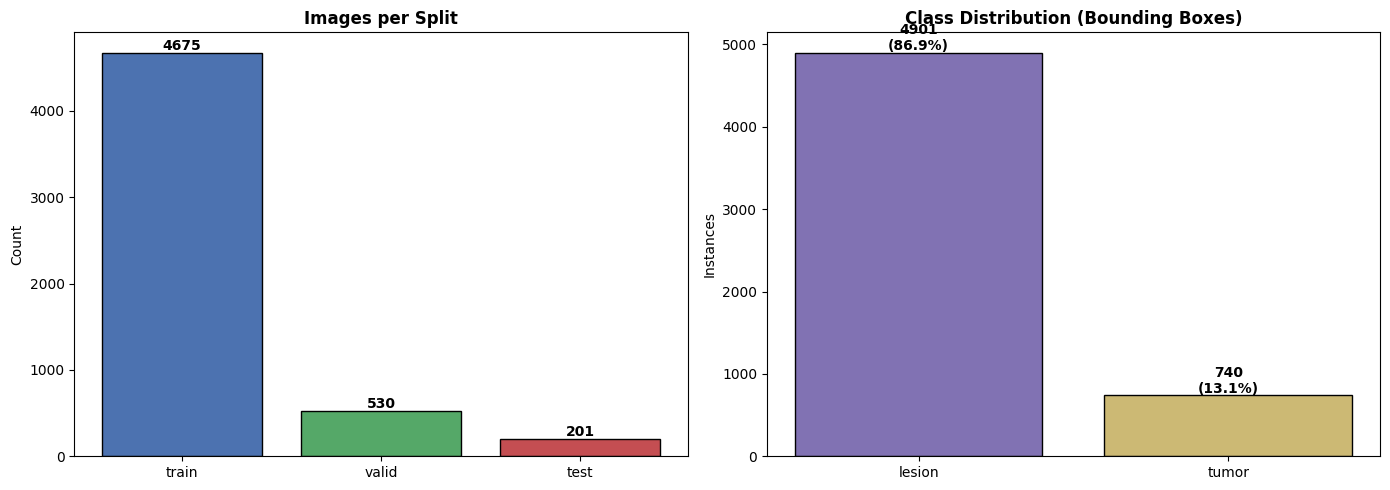


⚖️  Imbalance ratio: 6.6 : 1 (majority : minority)
   Decision: keep the natural prevalence (rebalancing would distort the test
   distribution); mitigate analytically via per-class metrics + FROC instead.


In [5]:
split_stats = {}
class_counts = Counter()

for split in splits:
    imgs = list_images(split)
    lbls = glob.glob(f'/content/breast_dataset/{split}/labels/*.txt')
    split_stats[split] = {'images': len(imgs), 'labels': len(lbls)}
    print(f"[{split.upper():5}] Images: {len(imgs):5} | Labels: {len(lbls):5}")

for lf in glob.glob('/content/breast_dataset/**/labels/*.txt', recursive=True):
    with open(lf, 'r', errors='ignore') as f:
        for line in f:
            p = line.strip().split()
            if len(p) == 5:
                class_counts[int(float(p[0]))] += 1

total_boxes = sum(class_counts.values())
print("-" * 55)
print(f"Total bounding boxes: {total_boxes}")
for cid, cnt in sorted(class_counts.items()):
    print(f"   {class_names[cid]:8}: {cnt:5} ({cnt / total_boxes * 100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sp_names = list(split_stats.keys())
sp_vals = [split_stats[s]['images'] for s in sp_names]
axes[0].bar(sp_names, sp_vals, color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black')
axes[0].set_title('Images per Split', fontweight='bold'); axes[0].set_ylabel('Count')
for i, v in enumerate(sp_vals):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

cls_lbls = [class_names[c] for c in sorted(class_counts)]
cls_vals = [class_counts[c] for c in sorted(class_counts)]
axes[1].bar(cls_lbls, cls_vals, color=['#8172B3', '#CCB974'], edgecolor='black')
axes[1].set_title('Class Distribution (Bounding Boxes)', fontweight='bold'); axes[1].set_ylabel('Instances')
for i, v in enumerate(cls_vals):
    axes[1].text(i, v + 30, f"{v}\n({v / total_boxes * 100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

imbalance_ratio = max(cls_vals) / min(cls_vals)
print(f"\n⚖️  Imbalance ratio: {imbalance_ratio:.1f} : 1 (majority : minority)")
print("   Decision: keep the natural prevalence (rebalancing would distort the test" )
print("   distribution); mitigate analytically via per-class metrics + FROC instead.")

## 6. Audit III — Bounding-Box Geometry
Lesion size distribution tells us what the detector will find hard: a box covering 2% of a 640-px image is ~13 px — near the detection floor. The center heatmap exposes positional annotation bias.

📦 BOX GEOMETRY (pixels @ native 640x640)
   Width  : min=11.0  median=81.0  max=532.0
   Height : min=8.0  median=85.0  max=515.0
   Boxes/image: mean=1.04  max=3


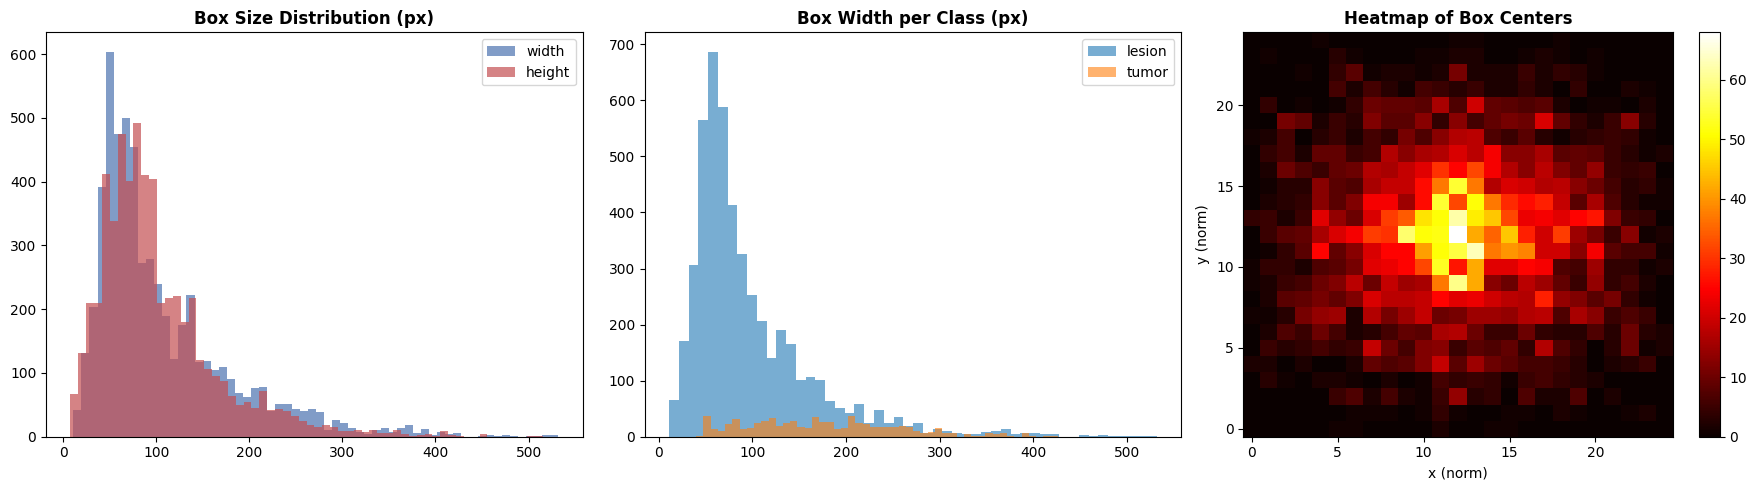

In [6]:
box_w_px, box_h_px, box_cx, box_cy = [], [], [], []
n_boxes_per_image = []
per_class_w = defaultdict(list)

for split in splits:
    for img_path in list_images(split):
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        n = 0
        lbl_path = label_path_for(img_path)
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r', errors='ignore') as f:
                for line in f:
                    p = line.strip().split()
                    if len(p) != 5:
                        continue
                    cid = int(float(p[0]))
                    cx, cy, bw, bh = map(float, p[1:])
                    box_cx.append(cx); box_cy.append(cy)
                    box_w_px.append(bw * w); box_h_px.append(bh * h)
                    per_class_w[cid].append(bw * w)
                    n += 1
        n_boxes_per_image.append(n)

print("📦 BOX GEOMETRY (pixels @ native 640x640)")
print(f"   Width  : min={min(box_w_px):.1f}  median={np.median(box_w_px):.1f}  max={max(box_w_px):.1f}")
print(f"   Height : min={min(box_h_px):.1f}  median={np.median(box_h_px):.1f}  max={max(box_h_px):.1f}")
print(f"   Boxes/image: mean={np.mean(n_boxes_per_image):.2f}  max={max(n_boxes_per_image)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(box_w_px, bins=60, alpha=0.7, label='width', color='#4C72B0')
axes[0].hist(box_h_px, bins=60, alpha=0.7, label='height', color='#C44E52')
axes[0].set_title('Box Size Distribution (px)', fontweight='bold'); axes[0].legend()
for cid in sorted(per_class_w):
    axes[1].hist(per_class_w[cid], bins=50, alpha=0.6, label=class_names[cid])
axes[1].set_title('Box Width per Class (px)', fontweight='bold'); axes[1].legend()
heat, _, _ = np.histogram2d(box_cx, box_cy, bins=25, range=[[0, 1], [0, 1]])
im = axes[2].imshow(heat.T, origin='lower', cmap='hot', aspect='auto')
axes[2].set_title('Heatmap of Box Centers', fontweight='bold')
axes[2].set_xlabel('x (norm)'); axes[2].set_ylabel('y (norm)')
plt.colorbar(im, ax=axes[2])
plt.tight_layout(); plt.show()

## 7. Audit IV — Rotation-Aware Data-Leakage Check
**The most dangerous silent failure in medical ML:** the same patient image in both train and test inflates test metrics and invalidates the study.

Here a plain hash check is **not enough** — the Roboflow export already contains 90°-rotated copies (Section 2). We therefore hash every image under **all four 0°/90°/180°/270° rotations** (perceptual aHash, tolerant to JPEG re-encoding) and flag cross-split collisions.

In [7]:
def ahash_rotations(path, size=16):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return []
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    hashes = []
    for k in range(4):  # 4 rotations: 0/90/180/270
        rot = np.rot90(img, k)
        hashes.append(tuple((rot > rot.mean()).flatten().tolist()))
    return hashes

hash_index = {}   # rotation-hash -> (split, path)
leaks = []

for split in splits:
    for img_path in list_images(split):
        for h in ahash_rotations(img_path):
            if h in hash_index:
                prev_split, prev_path = hash_index[h]
                if prev_split != split:
                    leaks.append((split, img_path, prev_split, prev_path))
            else:
                hash_index[h] = (split, img_path)

print("🔍 AUDIT IV — ROTATION-AWARE LEAKAGE CHECK (aHash, 4 rotations/image)")
print("-" * 66)
print(f"   Images hashed (x4 rotations): {len(list(hash_index)) // 4 if hash_index else 0}")
print(f"   Cross-split collisions      : {len(leaks)}")
if leaks:
    print("   ⚠️ POTENTIAL LEAKAGE — inspect these pairs before training:")
    for d in leaks[:10]:
        print("    ", d[0], os.path.basename(d[1]), "<->", d[2], os.path.basename(d[3]))
    print("   -> Recommended action: drop the colliding test/valid images.")
else:
    print("   ✅ PASS — no cross-split duplicates under any rotation. Splits are independent.")

🔍 AUDIT IV — ROTATION-AWARE LEAKAGE CHECK (aHash, 4 rotations/image)
------------------------------------------------------------------
   Images hashed (x4 rotations): 3020
   Cross-split collisions      : 124
   ⚠️ POTENTIAL LEAKAGE — inspect these pairs before training:
     valid C_0449_1-LEFT_CC_jpg.rf.f28120955a738cbc9980a442a47cf116.jpg <-> train D_4133_1-RIGHT_CC_jpg.rf.795aa35b4e4a7bd3409139236843a103.jpg
     valid C_0449_1-LEFT_CC_jpg.rf.f28120955a738cbc9980a442a47cf116.jpg <-> train D_4133_1-RIGHT_CC_jpg.rf.795aa35b4e4a7bd3409139236843a103.jpg
     valid C_0449_1-LEFT_CC_jpg.rf.f28120955a738cbc9980a442a47cf116.jpg <-> train D_4133_1-RIGHT_CC_jpg.rf.795aa35b4e4a7bd3409139236843a103.jpg
     valid C_0449_1-LEFT_CC_jpg.rf.f28120955a738cbc9980a442a47cf116.jpg <-> train D_4133_1-RIGHT_CC_jpg.rf.795aa35b4e4a7bd3409139236843a103.jpg
     valid mdb017ls_jpg.rf.b8ed9c5a66bb220351059726ea730990.jpg <-> train mdb017ls_jpg.rf.6506e527e54d3a0f7fa75fff4c28cadb.jpg
     valid mdb017ls_jpg

In [8]:
# ---- AUDIT IV-b: ACT ON THE LEAKAGE FOUND ABOVE, DON'T JUST REPORT IT ----
# Policy: valid/test are the held-out ground truth for model selection and reporting,
# so if a TRAIN image collides (under any rotation) with a valid/test image, the TRAIN
# copy is the one removed -- never touch valid/test. This directly protects early-stopping
# / best-checkpoint selection (which is driven by the valid split) from leakage.
train_leak_imgs = sorted({img for (split, img, other_split, other_img) in leaks if split == 'train'}
                          | {other_img for (split, img, other_split, other_img) in leaks if other_split == 'train'})

removed_imgs, removed_lbls = [], []
for img_path in train_leak_imgs:
    if '/train/' not in img_path.replace('\\', '/'):
        continue  # safety: never remove anything outside train
    lbl_path = label_path_for(img_path)
    if os.path.exists(img_path):
        os.remove(img_path); removed_imgs.append(img_path)
    if os.path.exists(lbl_path):
        os.remove(lbl_path); removed_lbls.append(lbl_path)

print(f"LEAKAGE REMEDIATION")
print("-" * 66)
print(f"   Train images removed (colliding with valid/test): {len(removed_imgs)}")
print(f"   Train label files removed                        : {len(removed_lbls)}")
print(f"   Train set size after cleanup                      : {len(list_images('train'))}")
if removed_imgs:
    print("   (valid/test were left untouched -- they remain the held-out ground truth)")


LEAKAGE REMEDIATION
------------------------------------------------------------------
   Train images removed (colliding with valid/test): 28
   Train label files removed                        : 28
   Train set size after cleanup                      : 4647
   (valid/test were left untouched -- they remain the held-out ground truth)


## 8. Audit V — (Optional) CLAHE Enhancement Demo
Mammograms are low-contrast; **CLAHE** is the classical remedy. Published YOLO mammography work found CLAHE *at inference time* recovered ~50% of otherwise-missed low-quality images — so we treat it as a **documented ablation option**, not a default. Ultralytics already augments (HSV, flip, mosaic, RandAugment), and the dataset is already 3× rotation-augmented by Roboflow.

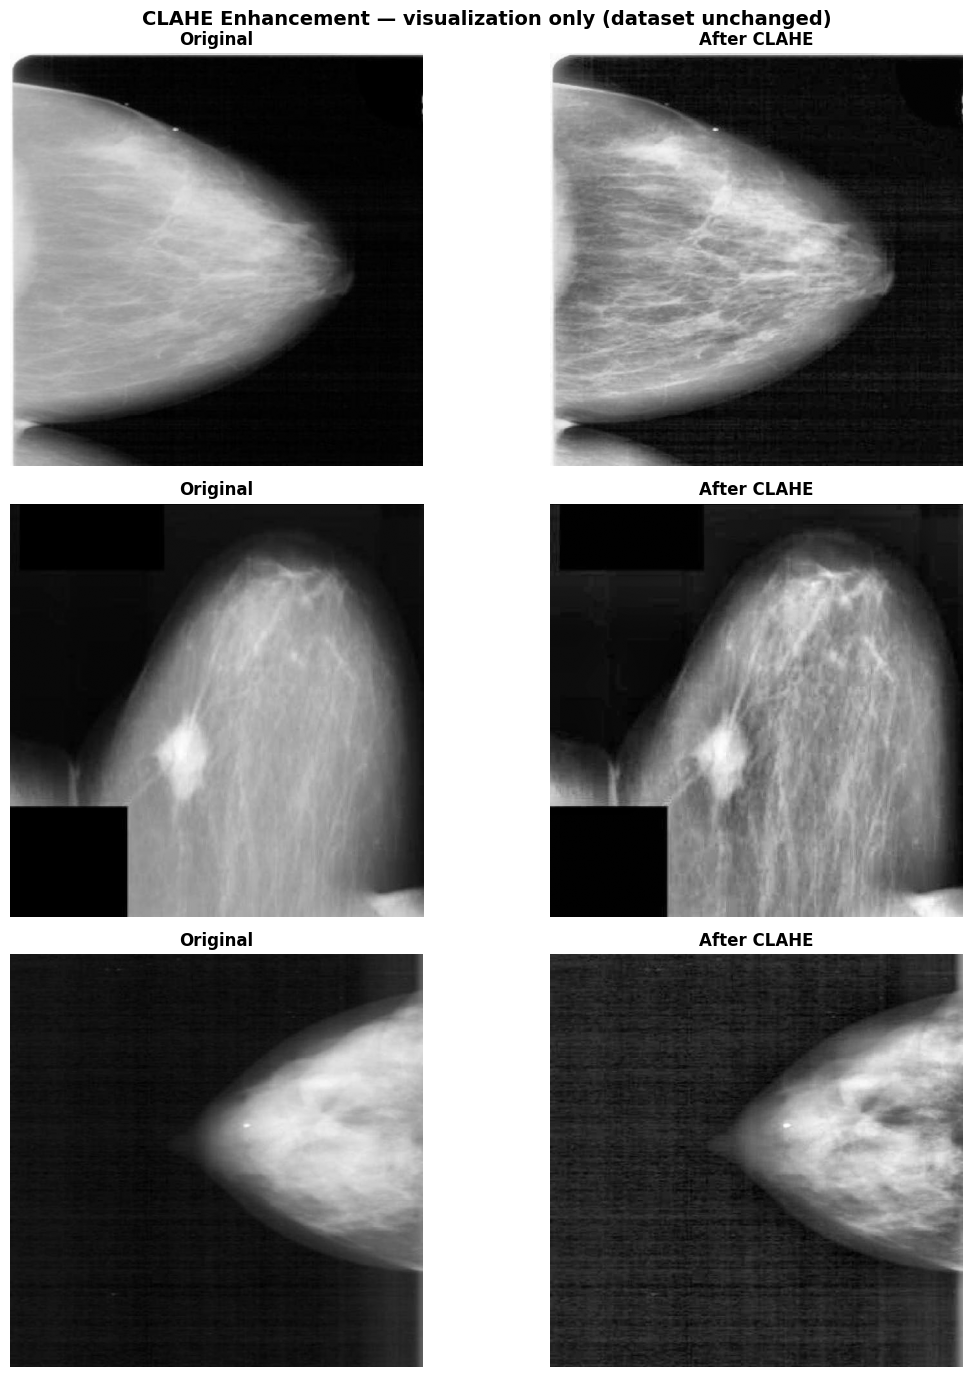

In [9]:
APPLY_CLAHE = False   # ⚠️ keep False unless running the dedicated CLAHE ablation

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
samples = random.Random(SEED).sample(list_images('train'), 3)

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
for row, p in enumerate(samples):
    gray = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2GRAY)
    axes[row, 0].imshow(gray, cmap='gray'); axes[row, 0].set_title('Original', fontweight='bold')
    axes[row, 1].imshow(clahe.apply(gray), cmap='gray'); axes[row, 1].set_title('After CLAHE', fontweight='bold')
    for ax in axes[row]:
        ax.axis('off')
plt.suptitle('CLAHE Enhancement — visualization only (dataset unchanged)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Data Quality Audit — Summary
One auditable table for the report.

In [10]:
print("=" * 68)
print("📋 DATA QUALITY AUDIT — SUMMARY")
print("=" * 68)
rows = [
    ("Total images", sum(v['images'] for v in split_stats.values())),
    ("Train / Valid / Test", f"{split_stats['train']['images']} / {split_stats['valid']['images']} / {split_stats['test']['images']}"),
    ("Total bounding boxes", total_boxes),
    ("Classes", f"{class_names} (nc={NUM_CLASSES})"),
    ("Class imbalance (maj:min)", f"{imbalance_ratio:.1f} : 1"),
    ("Corrupt images", sum(len(integrity[s]['corrupt_img']) for s in splits)),
    ("Missing labels", sum(len(integrity[s]['missing_label']) for s in splits)),
    ("Invalid label lines", sum(len(integrity[s]['bad_lines']) for s in splits)),
    ("Out-of-range coords", sum(len(integrity[s]['out_of_range']) for s in splits)),
    ("Cross-split leakage (rotation-aware)", len(leaks)),
]
for k, v in rows:
    print(f"   {k:<38}: {v}")
print("=" * 68)
n_removed = len(removed_imgs) if "removed_imgs" in dir() else 0
print(f"✅ Dataset audited, profiled, and {n_removed} leaking train image(s) removed before training.")

📋 DATA QUALITY AUDIT — SUMMARY
   Total images                          : 5406
   Train / Valid / Test                  : 4675 / 530 / 201
   Total bounding boxes                  : 5641
   Classes                               : ['lesion', 'tumor'] (nc=2)
   Class imbalance (maj:min)             : 6.6 : 1
   Corrupt images                        : 0
   Missing labels                        : 0
   Invalid label lines                   : 0
   Out-of-range coords                   : 0
   Cross-split leakage (rotation-aware)  : 124
✅ Dataset audited, profiled, and 28 leaking train image(s) removed before training.


---
## Part C — Training, Diagnosis & Clinical Evaluation
## 10. Ground-Truth Visualization
Final sanity check: boxes must align with actual lesions. Color code: 🟩 `lesion` · 🟥 `tumor`.

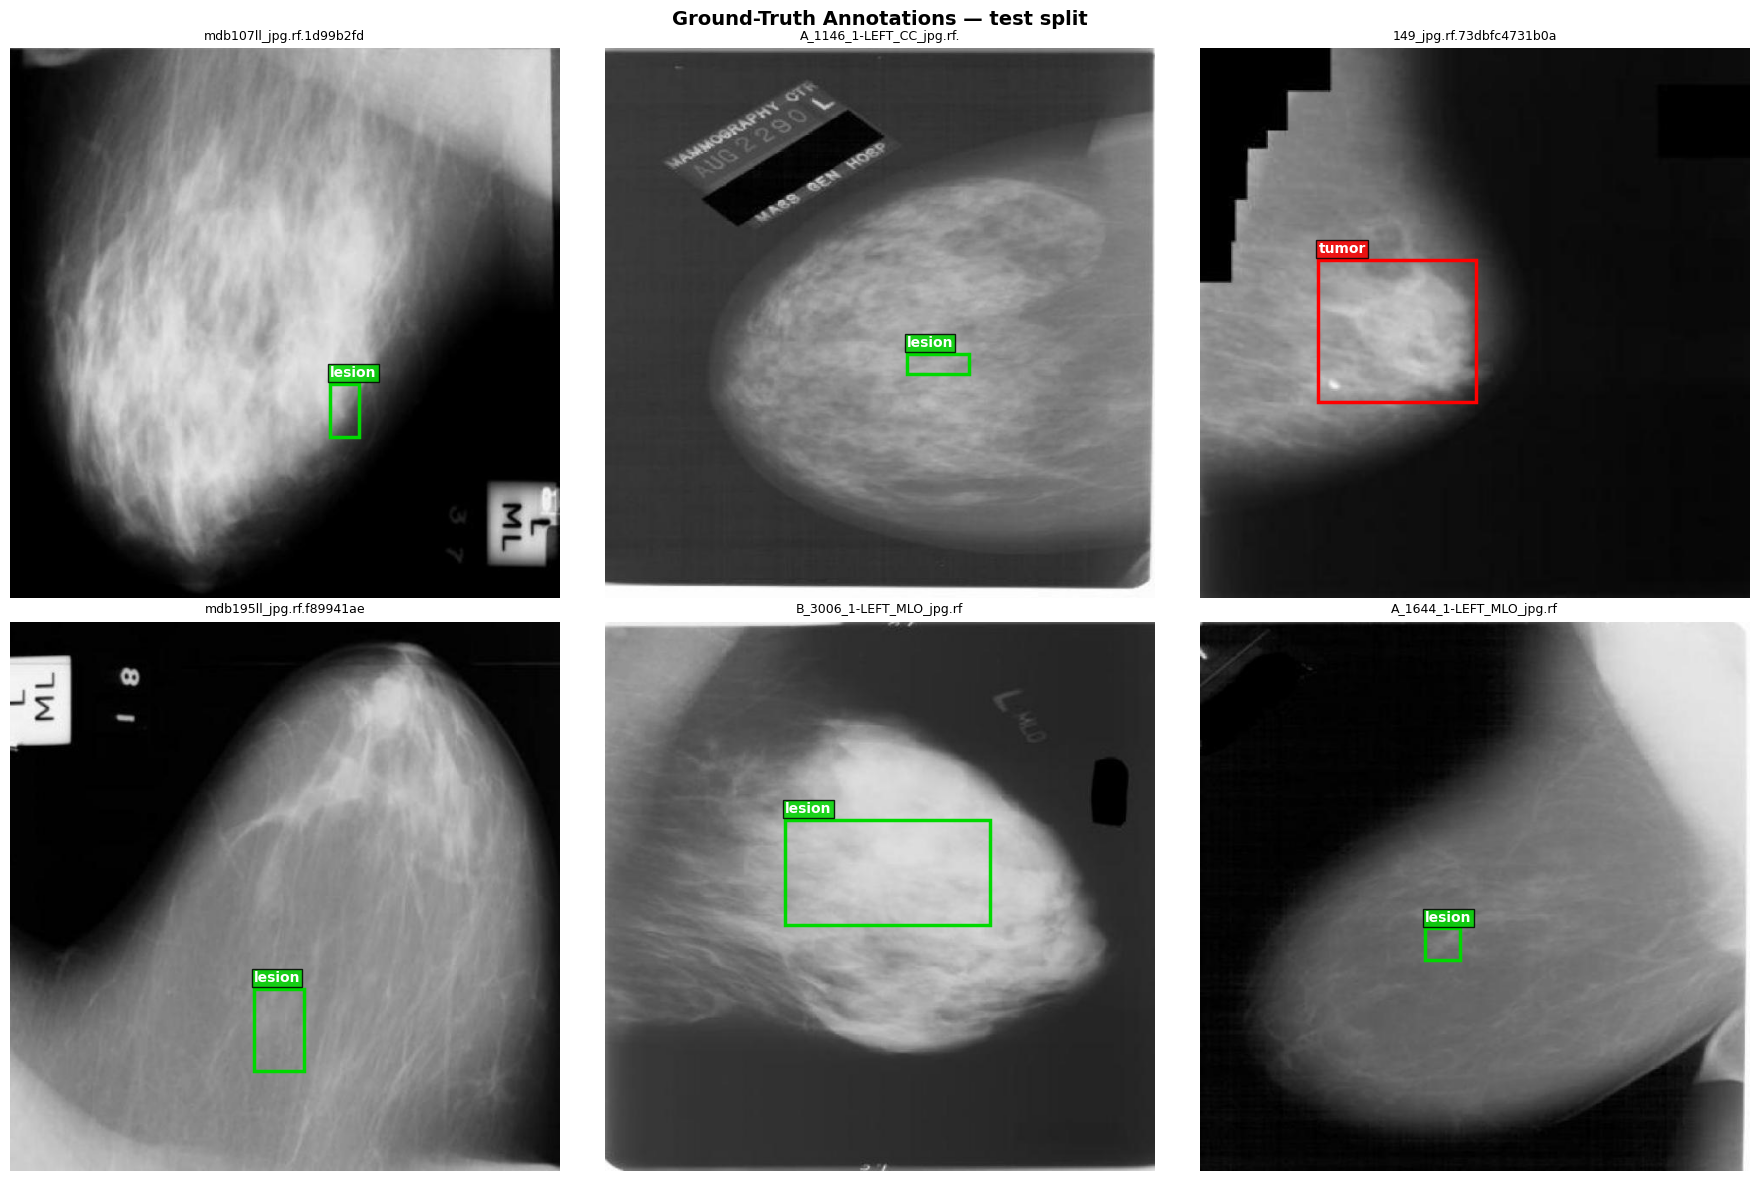

In [11]:
CLASS_COLORS_RGB = {0: (0, 0.85, 0), 1: (1, 0, 0)}

def visualize_yolo_samples(split='test', num_samples=6, seed=SEED):
    rng = random.Random(seed)
    img_files = list_images(split)
    selected = rng.sample(img_files, min(num_samples, len(img_files)))
    ncols = 3
    nrows = int(np.ceil(len(selected) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, img_path in enumerate(selected):
        ax = axes[i]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lbl_path = label_path_for(img_path)
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    p = line.strip().split()
                    if len(p) != 5:
                        continue
                    cid = int(float(p[0]))
                    cx, cy, bw, bh = map(float, p[1:])
                    x1 = (cx - bw / 2) * w; y1 = (cy - bh / 2) * h
                    color = CLASS_COLORS_RGB.get(cid, (1, 1, 0))
                    ax.add_patch(plt.Rectangle((x1, y1), bw * w, bh * h,
                                               fill=False, edgecolor=color, linewidth=2.5))
                    ax.text(x1, max(y1 - 8, 12), class_names[cid], color='white',
                            fontsize=10, fontweight='bold',
                            bbox=dict(facecolor=color, alpha=0.85, pad=1.5))
        ax.imshow(img)
        ax.set_title(os.path.basename(img_path)[:24], fontsize=9)
        ax.axis('off')
    for j in range(len(selected), len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Ground-Truth Annotations — {split} split', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

visualize_yolo_samples('test', 6)

## 11. Model Training — YOLO11s with Transfer Learning

**Hyperparameter justification (report-ready):**

| Choice | Value | Justification |
|:---|:---|:---|
| Backbone | `yolo11s.pt` (9.4M params) | Sufficient capacity for 2 classes; smaller models overfit less on ~4.7k images |
| Init | COCO pretrained | Transfer learning converges faster and generalizes better than scratch |
| Epochs | 70 + `patience=15` | Long horizon, early stopping protects against over-training |
| LR schedule | `cos_lr=True` | Cosine decay → smooth late-stage convergence |
| Batch / imgsz | 8 / 640 | 640 is the dataset's **native** size (Roboflow pre-resize); batch 8 fits a T4 |
| Seed | 42 | Bit-level reproducibility |
| `hsv_h` / `hsv_s` | 0.0 / 0.0 | Mammograms are grayscale; Ultralytics' default hue/saturation jitter has no real color signal to act on and just adds noise the model has to learn to ignore. `hsv_v` (brightness jitter) is kept, since scanner exposure genuinely varies. |


> **Note on vertical flip:** an earlier draft of this notebook argued for disabling `flipud` as "anatomically implausible." That argument doesn't actually hold here: Roboflow's own augmentation for this dataset (Section 2) already includes upside-down (180°) rotated copies by the dataset creators' own design, so `flipud` is left at its Ultralytics default rather than forced to 0.

In [12]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")   # pretrained small backbone

results = model.train(
    data=data_yaml,
    epochs=70,
    imgsz=640,
    batch=8,
    patience=15,             # early stopping safety net
    cos_lr=True,             # cosine LR decay
    seed=SEED,
    hsv_h=0.0,                # mammograms are grayscale -> hue jitter is meaningless noise
    hsv_s=0.0,                # same: no real saturation info to jitter on a grayscale scan
    hsv_v=0.3,                # keep brightness/exposure jitter -- scanners vary in exposure
    project="/content/breast_cancer_results",
    name="yolo11s_run",
    plots=True               # auto-save curves + confusion matrix
)
exp_dir = str(results.save_dir)
print(f"\n📁 Training artifacts: {exp_dir}")

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/breast_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_run, nbs=64, nms=None, opset=None, opti

## 12. Training-Dynamics Diagnosis — *Is the Model Memorizing?*
The standard test from the Ultralytics/Google playbook: **training loss keeps falling while validation loss climbs → overfitting**. We parse `results.csv` and issue an automated, criteria-based verdict:

| Pattern | Diagnosis |
|:---|:---|
| val loss rises >5% above its minimum after the best epoch | Overfitting |
| val loss flat / still falling at the end | Under-trained → train longer |
| val loss tracks train loss and plateaus together | Healthy convergence |

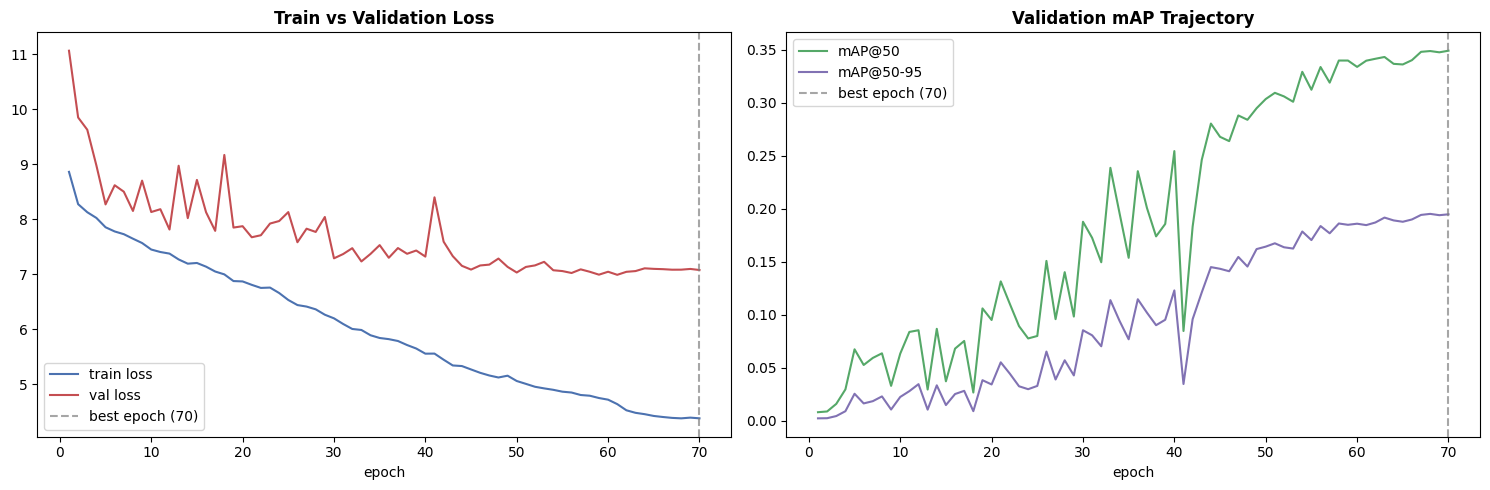

🩺 AUTOMATED OVERFITTING DIAGNOSIS
   Epochs completed        : 70
   Best val mAP@50 epoch   : 70  (mAP@50=0.3490)
   Val-loss minimum epoch  : 61
   Val loss: min=6.9881  final=7.0755  drift=+1.3%
------------------------------------------------------------------
   ⏳ VERDICT: under-trained — val loss still improving at the end.
      -> retrain with more epochs (e.g., 100) to capture full potential


In [13]:
csv_path = os.path.join(exp_dir, 'results.csv')
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

train_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
val_loss   = df['val/box_loss']   + df['val/cls_loss']   + df['val/dfl_loss']
map50      = df['metrics/mAP50(B)']
map5095    = df['metrics/mAP50-95(B)']
epochs_ax  = np.arange(1, len(df) + 1)

best_ep     = int(np.argmax(map50)) + 1
val_min_ep  = int(np.argmin(val_loss)) + 1
final_val   = float(val_loss.iloc[-1])
min_val     = float(val_loss.min())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(epochs_ax, train_loss, label='train loss', color='#4C72B0')
axes[0].plot(epochs_ax, val_loss,   label='val loss',   color='#C44E52')
axes[0].axvline(best_ep, ls='--', c='gray', alpha=0.7, label=f'best epoch ({best_ep})')
axes[0].set_title('Train vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(epochs_ax, map50,   label='mAP@50',    color='#55A868')
axes[1].plot(epochs_ax, map5095, label='mAP@50-95', color='#8172B3')
axes[1].axvline(best_ep, ls='--', c='gray', alpha=0.7, label=f'best epoch ({best_ep})')
axes[1].set_title('Validation mAP Trajectory', fontweight='bold')
axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

print("=" * 66)
print("🩺 AUTOMATED OVERFITTING DIAGNOSIS")
print("=" * 66)
print(f"   Epochs completed        : {len(df)}")
print(f"   Best val mAP@50 epoch   : {best_ep}  (mAP@50={map50.max():.4f})")
print(f"   Val-loss minimum epoch  : {val_min_ep}")
print(f"   Val loss: min={min_val:.4f}  final={final_val:.4f}  drift={100 * (final_val - min_val) / min_val:+.1f}%")
print("-" * 66)
if final_val > min_val * 1.05 and best_ep < len(df) - 10:
    print("   ⚠️ VERDICT: overfitting detected after epoch", val_min_ep)
    print("      -> early stopping already protects you: best.pt is used, not last.pt")
    print("      -> optional: stronger augmentation / weight decay / fewer epochs")
elif val_loss.iloc[-1] <= min_val * 1.02 and best_ep >= len(df) - 5:
    print("   ⏳ VERDICT: under-trained — val loss still improving at the end.")
    print("      -> retrain with more epochs (e.g., 100) to capture full potential")
else:
    print("   ✅ VERDICT: healthy convergence — train/val curves track and plateau together.")
    print("      best.pt stands on a stable plateau; no memorization signature.")
print("=" * 66)

## 13. Quantitative Evaluation — Unseen Test Split
The test split (201 images) was never touched during training or model selection. We report overall **and** per-class metrics — with imbalanced data, the overall figure alone can hide minority-class failure. **Tumor recall is the clinically critical number** (a missed tumor costs far more than a false alarm).

In [14]:
best_pt_path = os.path.join(exp_dir, 'weights', 'best.pt')
if not os.path.exists(best_pt_path):
    found = glob.glob('/content/breast_cancer_results/**/best.pt', recursive=True)
    best_pt_path = found[0]
print(f"Evaluating: {best_pt_path}")
best_model = YOLO(best_pt_path)

test_metrics = best_model.val(data=data_yaml, split="test", conf=0.30)

print("\n" + "=" * 60)
print("📊 FINAL TEST METRICS (COCO-style)")
print("=" * 60)
print(f"   Mean Precision : {test_metrics.box.p.mean():.4f}")
print(f"   Mean Recall    : {test_metrics.box.r.mean():.4f}")
print(f"   mAP@50         : {test_metrics.box.map50:.4f}")
print(f"   mAP@50-95      : {test_metrics.box.map:.4f}")
print("-" * 60)
print("Per-class breakdown:")
for i, name in enumerate(class_names):
    print(f"   [{name:>6}] P={test_metrics.box.p[i]:.3f}  R={test_metrics.box.r[i]:.3f}  "
          f"mAP50={test_metrics.box.ap50[i]:.3f}  mAP50-95={test_metrics.box.ap[i]:.3f}")
print("=" * 60)

Evaluating: /content/breast_cancer_results/yolo11s_run/weights/best.pt
Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 858.6±231.4 MB/s, size: 22.1 KB)
val: Scanning /content/breast_dataset/test/labels... 201 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 201/201 2.3Kit/s 0.1s
val: New cache created: /content/breast_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.0it/s 4.4s
                   all        201        208      0.651      0.457       0.43      0.245
                lesion        178        179      0.703      0.397      0.377      0.261
                 tumor         23         29        0.6      0.517      0.482      0.228
Speed: 3.5ms preprocess, 9.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Resul

## 14. Saved Curves — Confusion Matrix, F1 & PR
- **Confusion matrix:** which class gets confused with background.
- **F1–confidence curve:** the principled way to pick the operating threshold (used in Section 15).

📈 Full training curves (auto-saved)


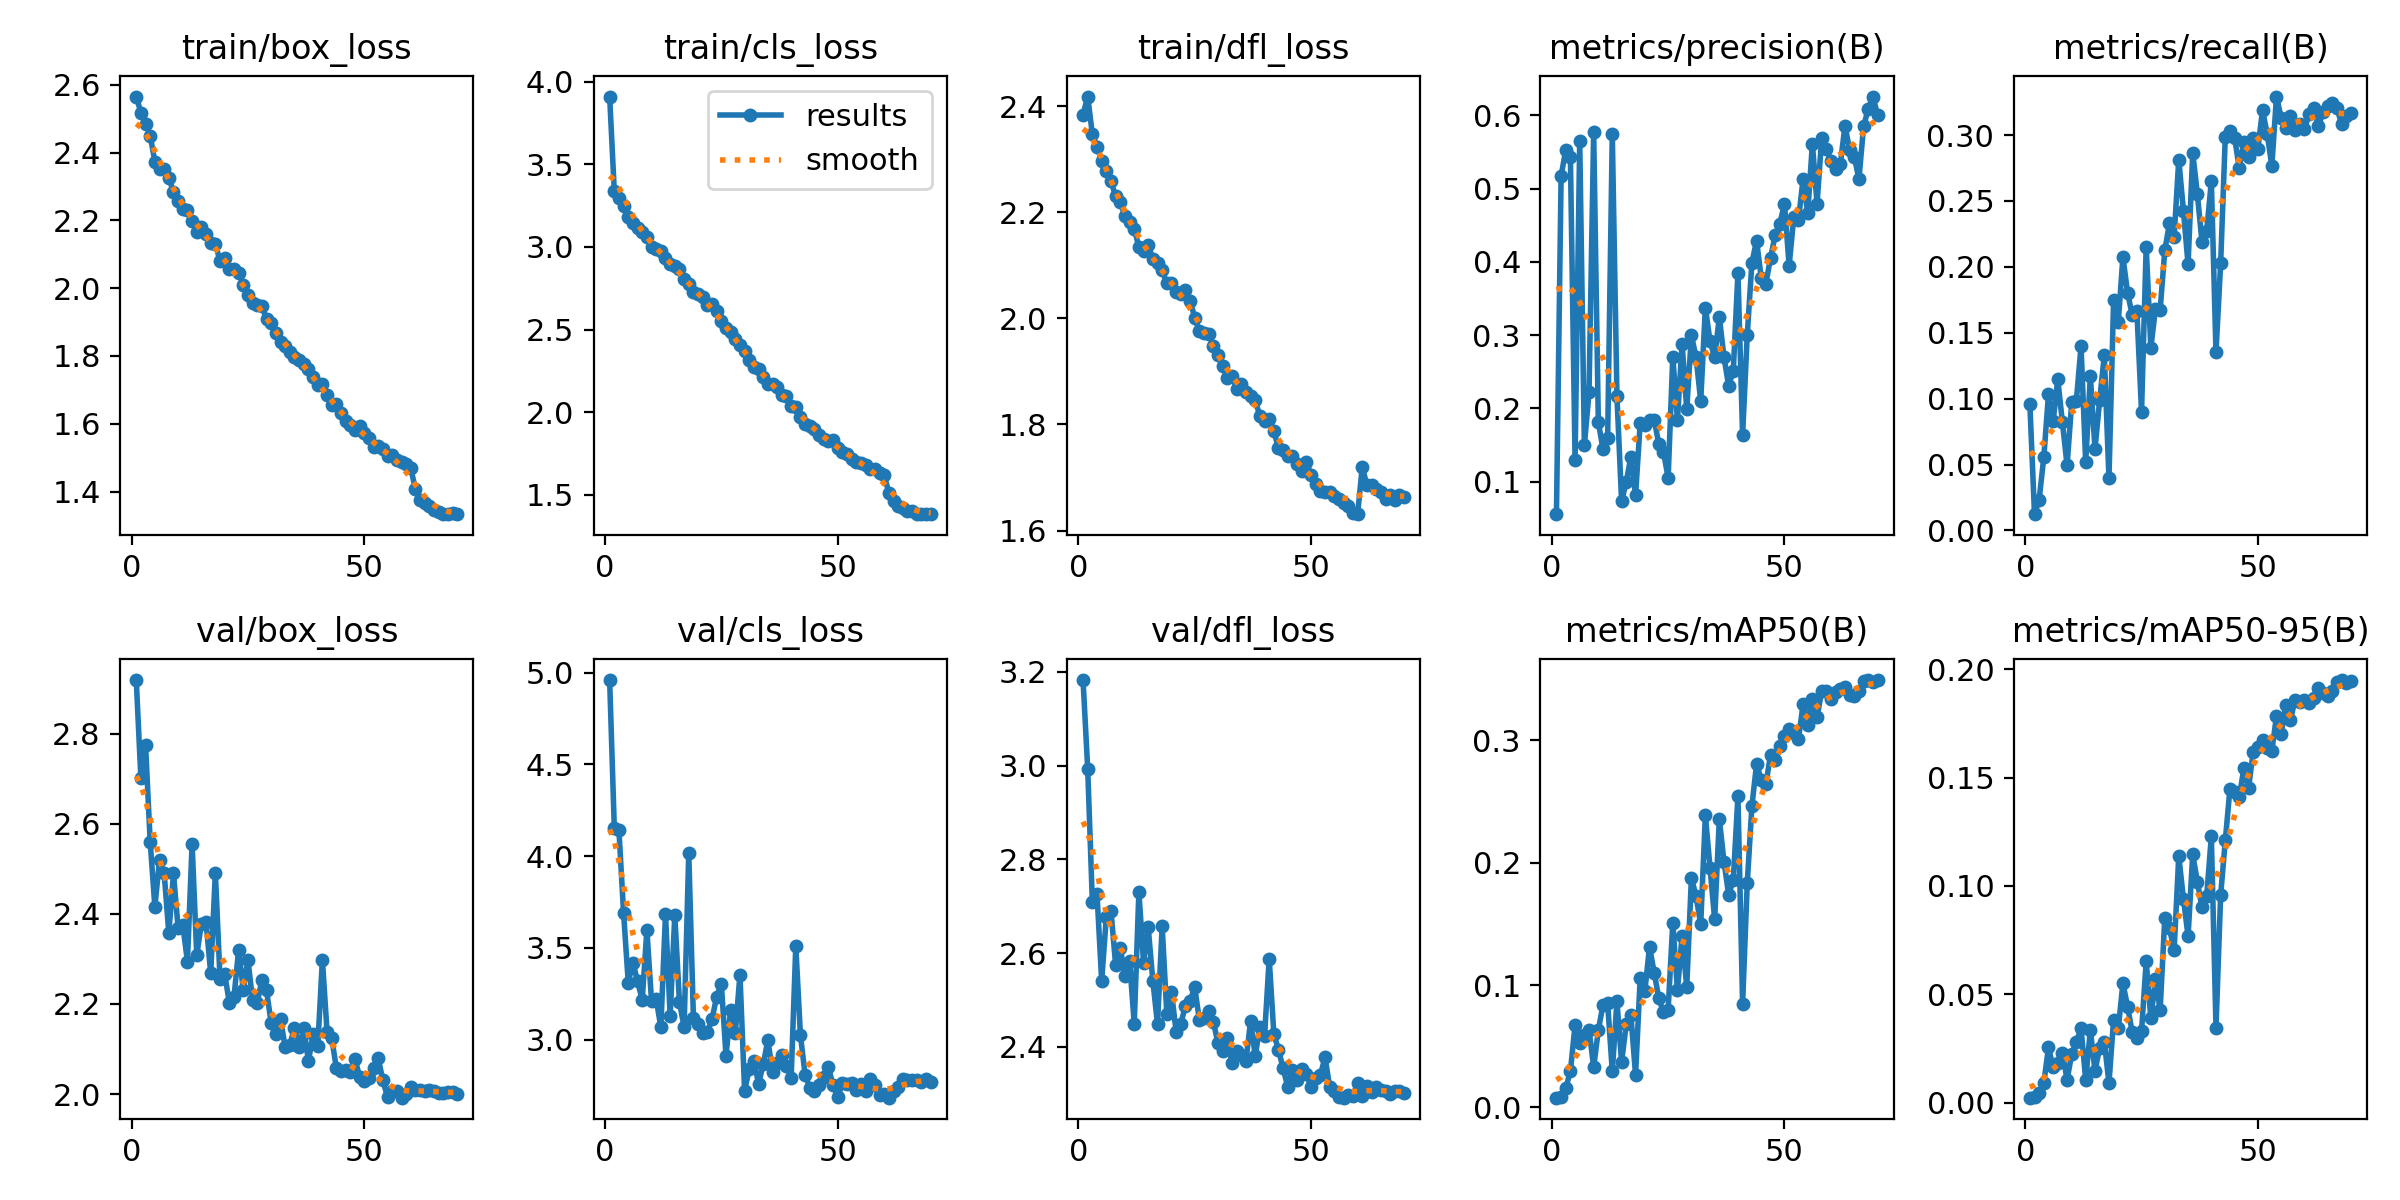

🔍 Confusion Matrix


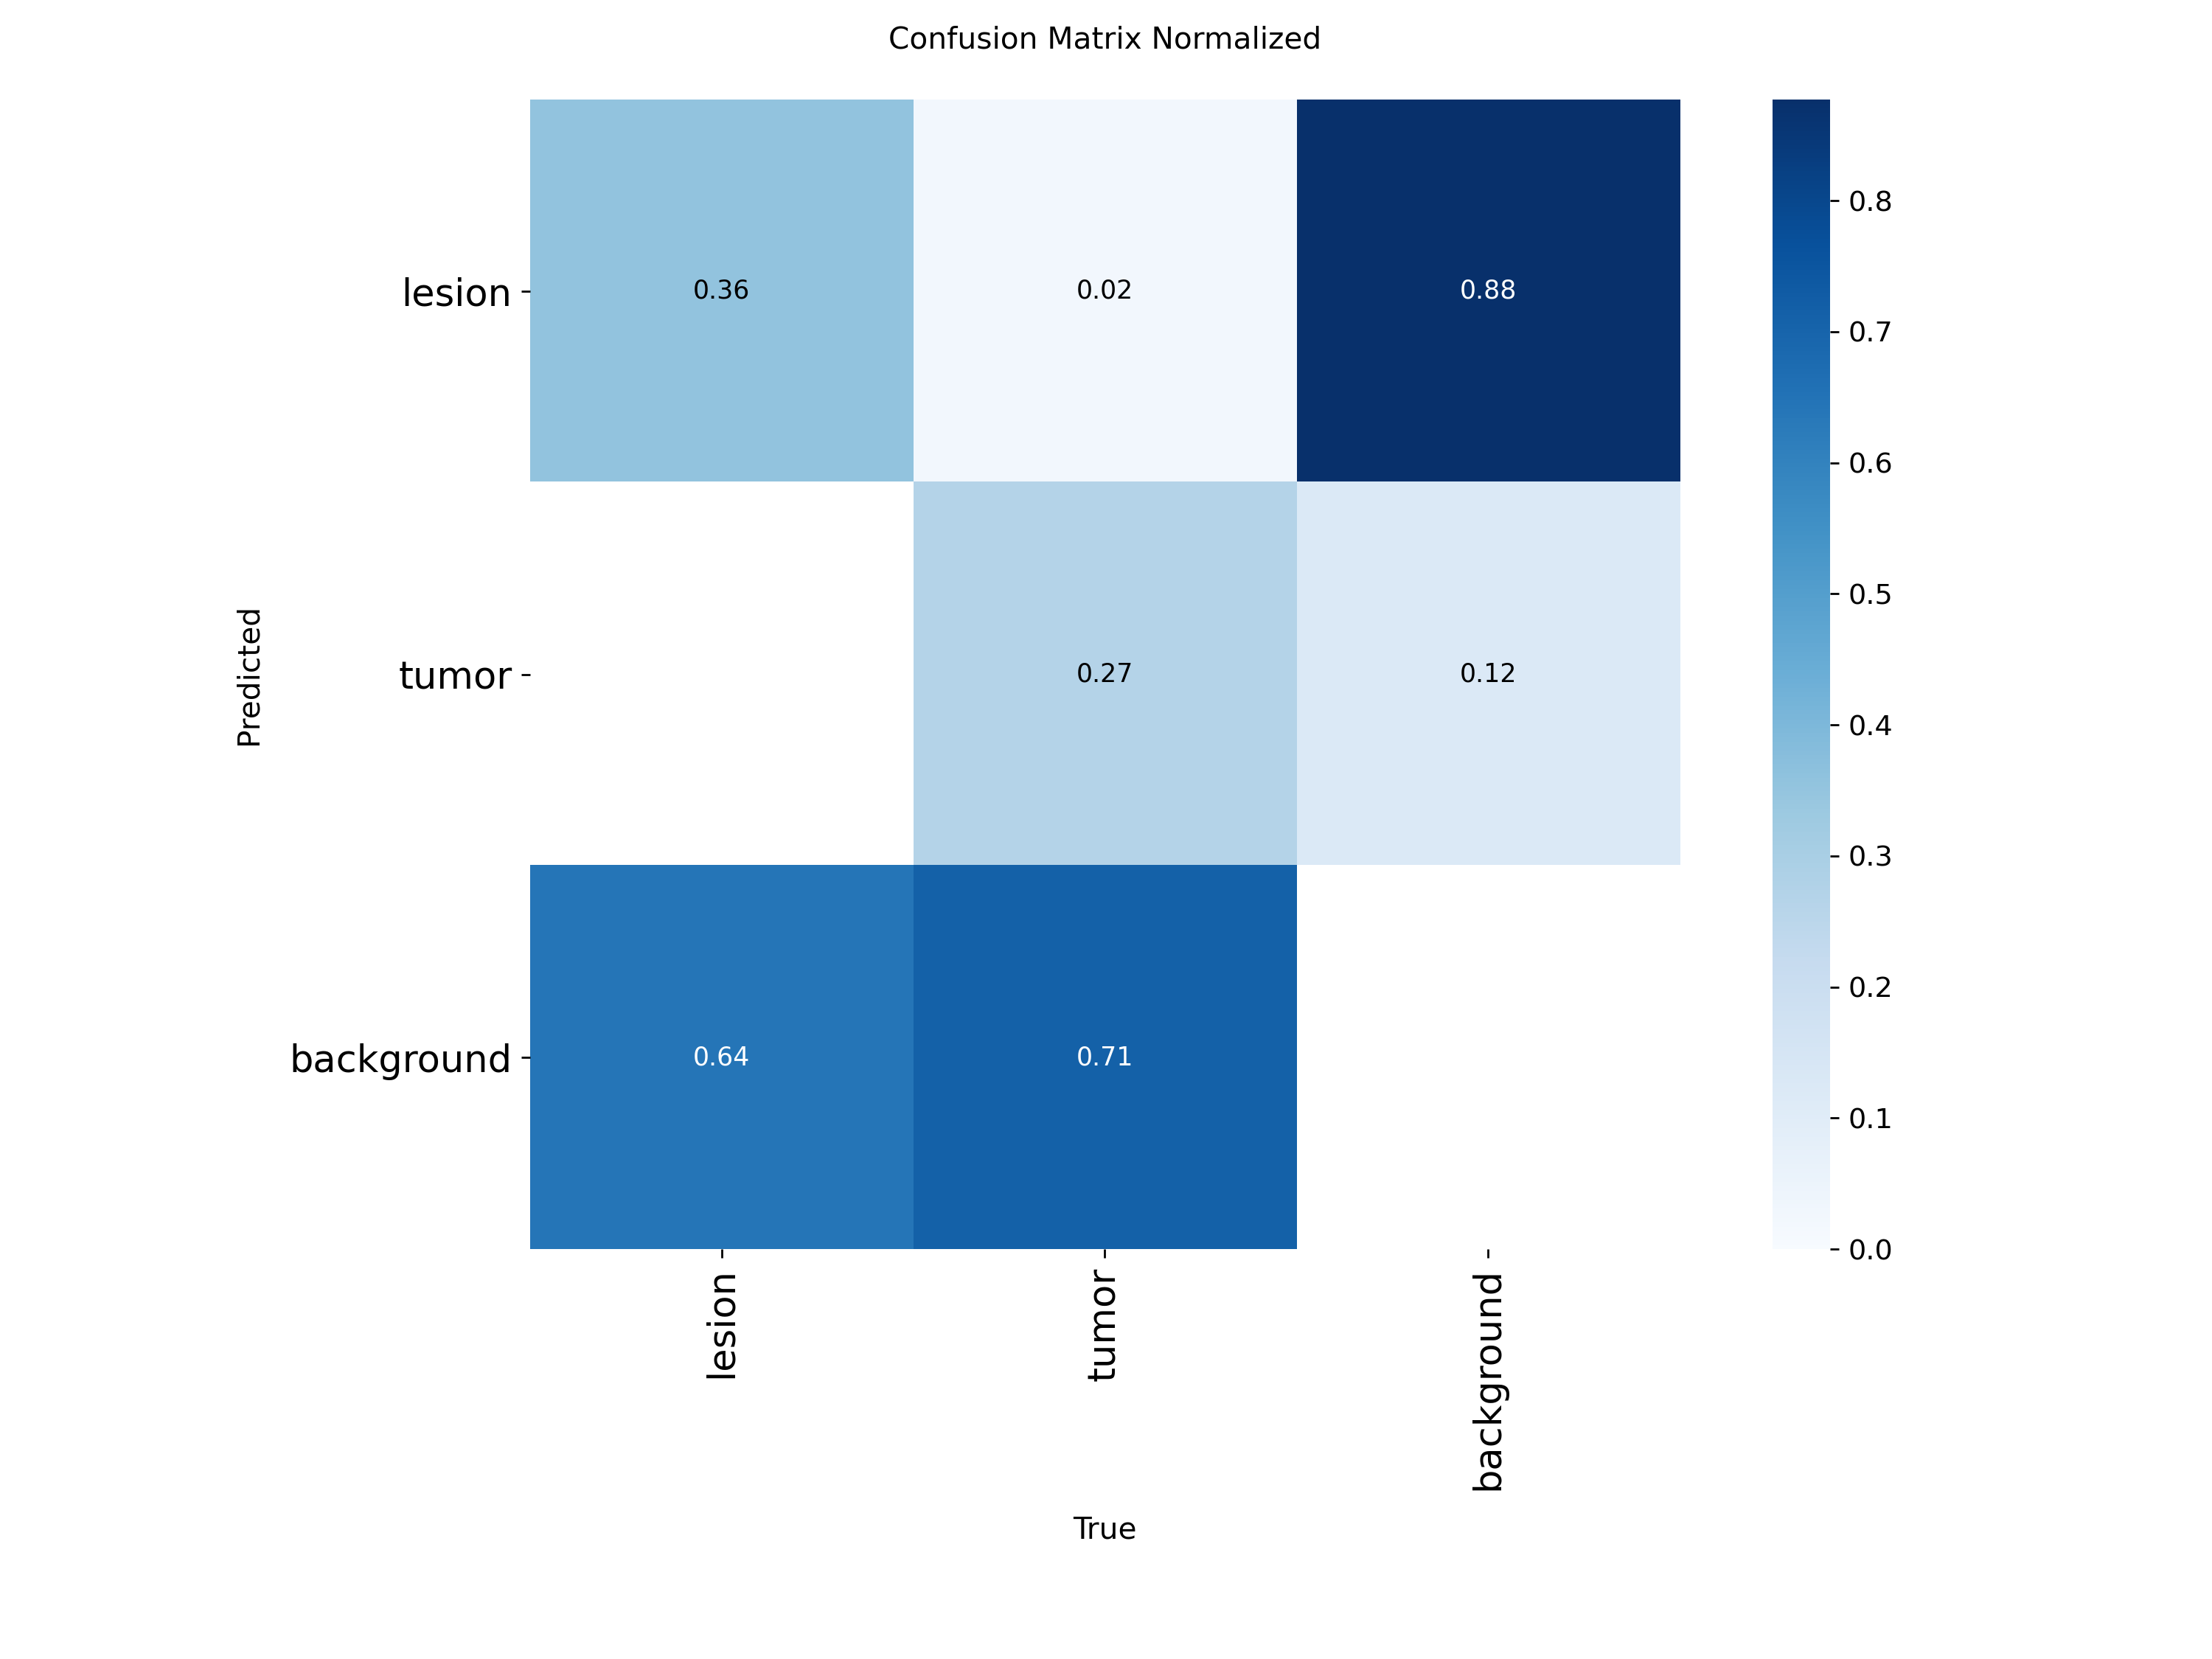

🎯 F1 vs Confidence


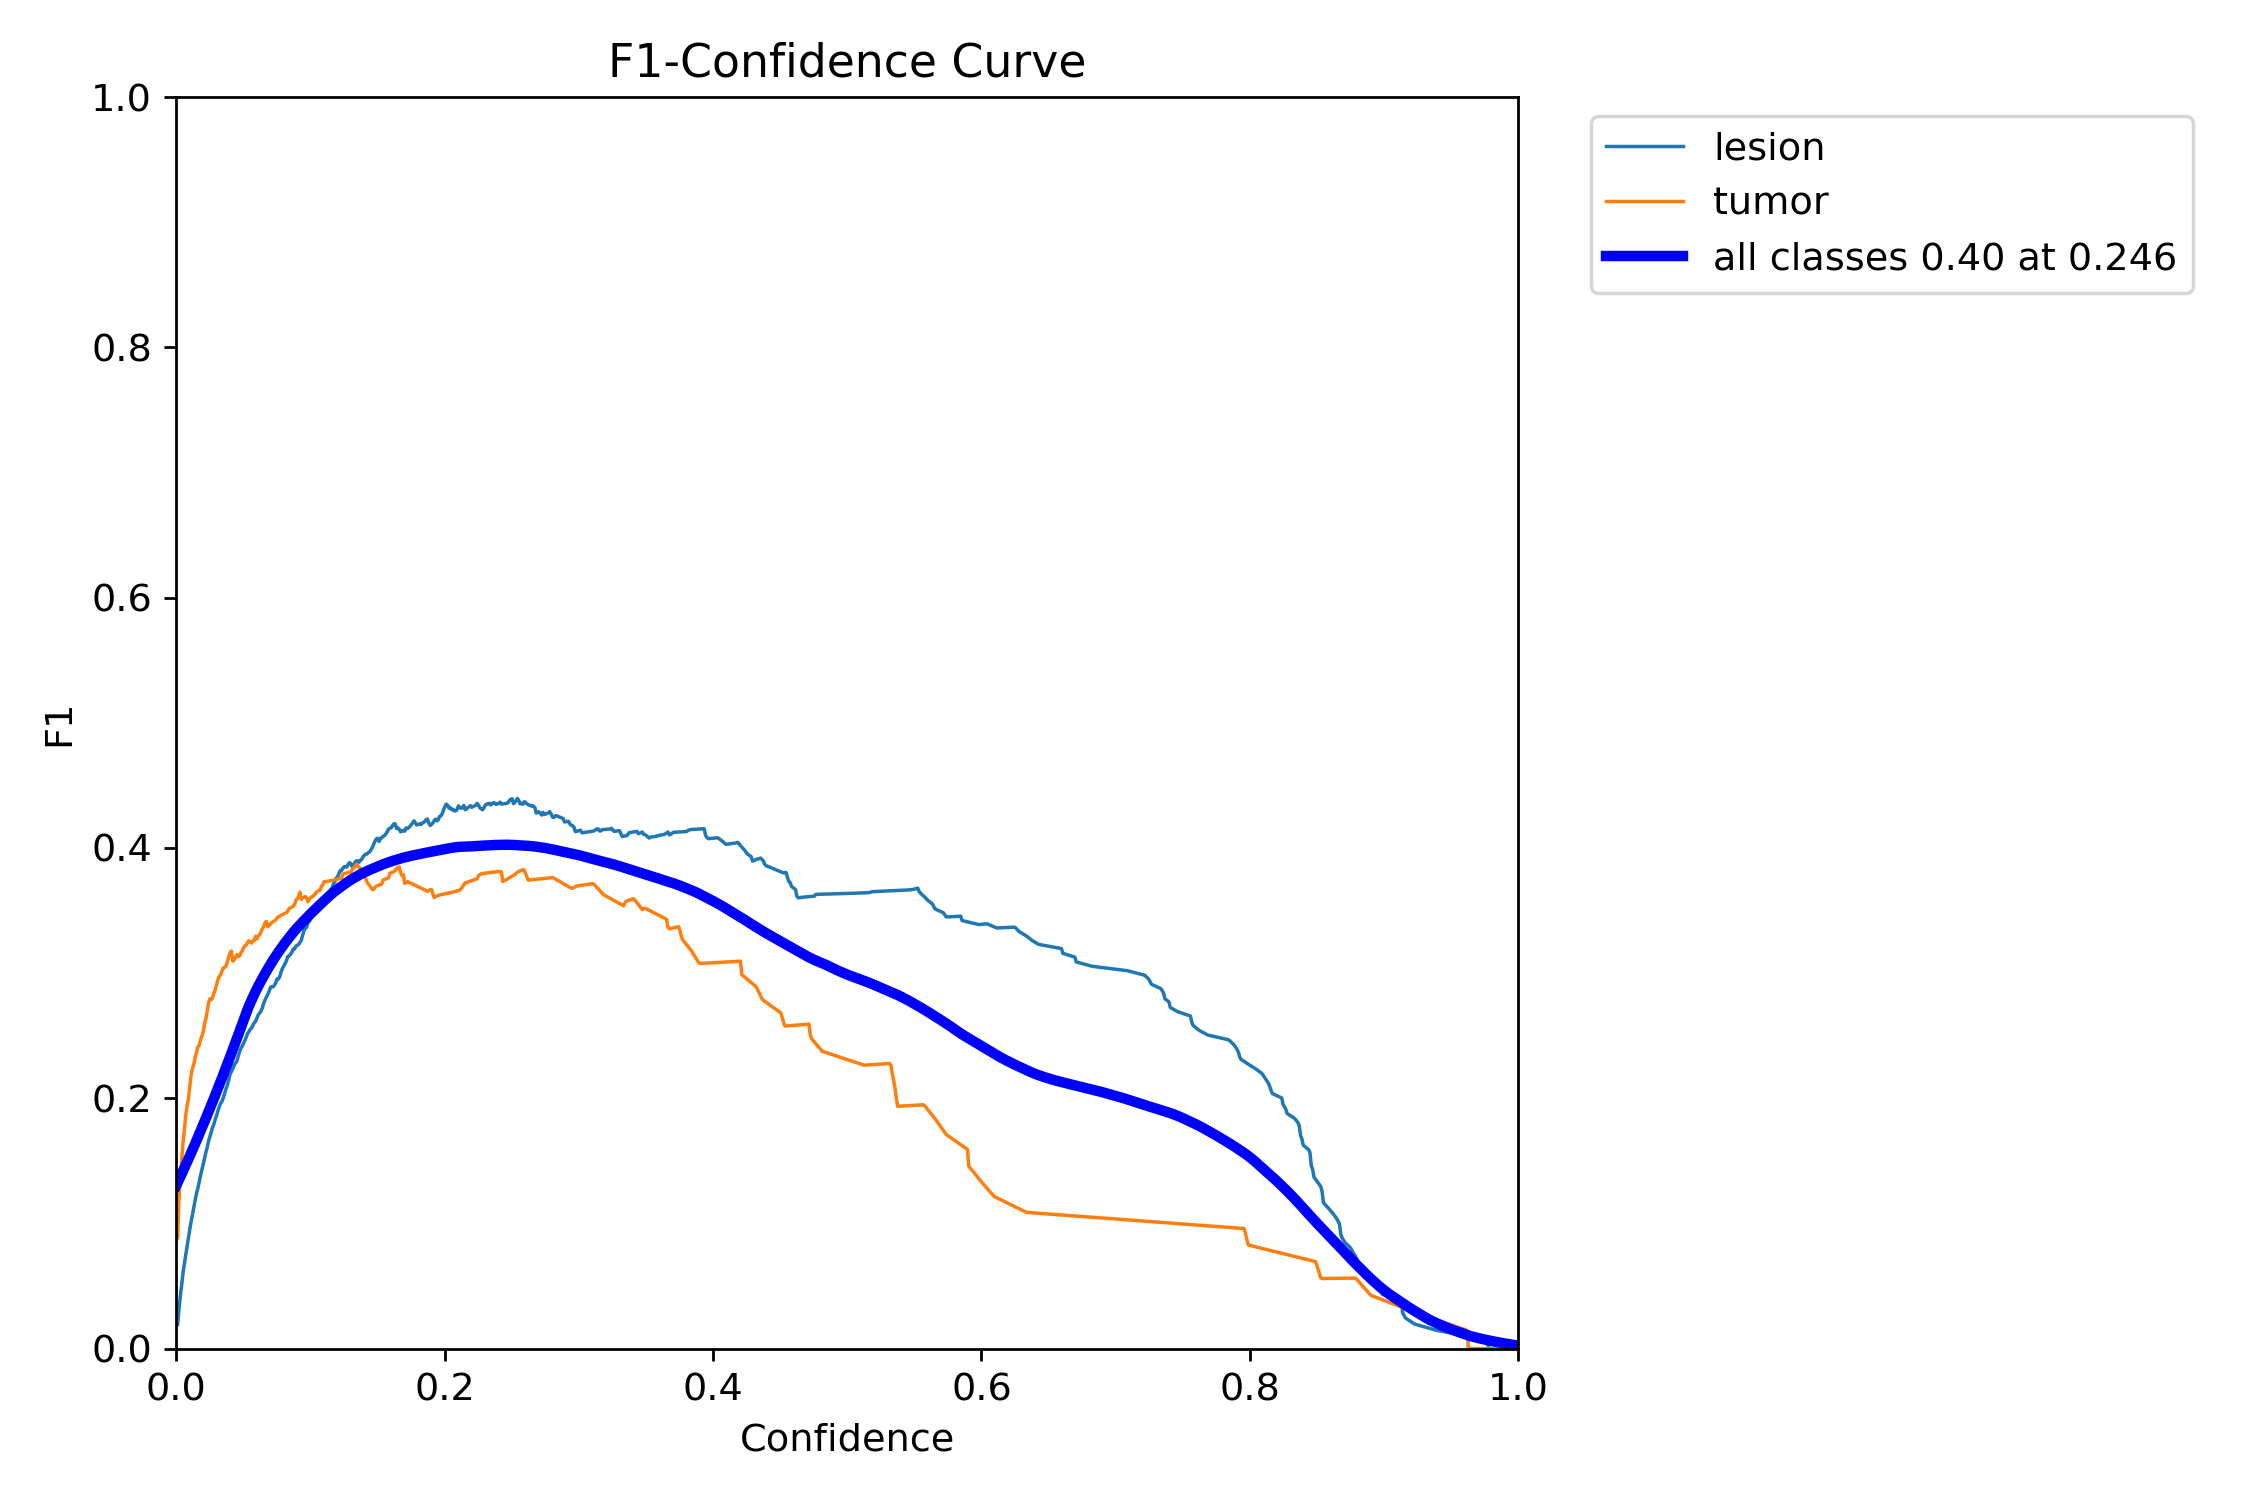

📉 Precision–Recall Curve


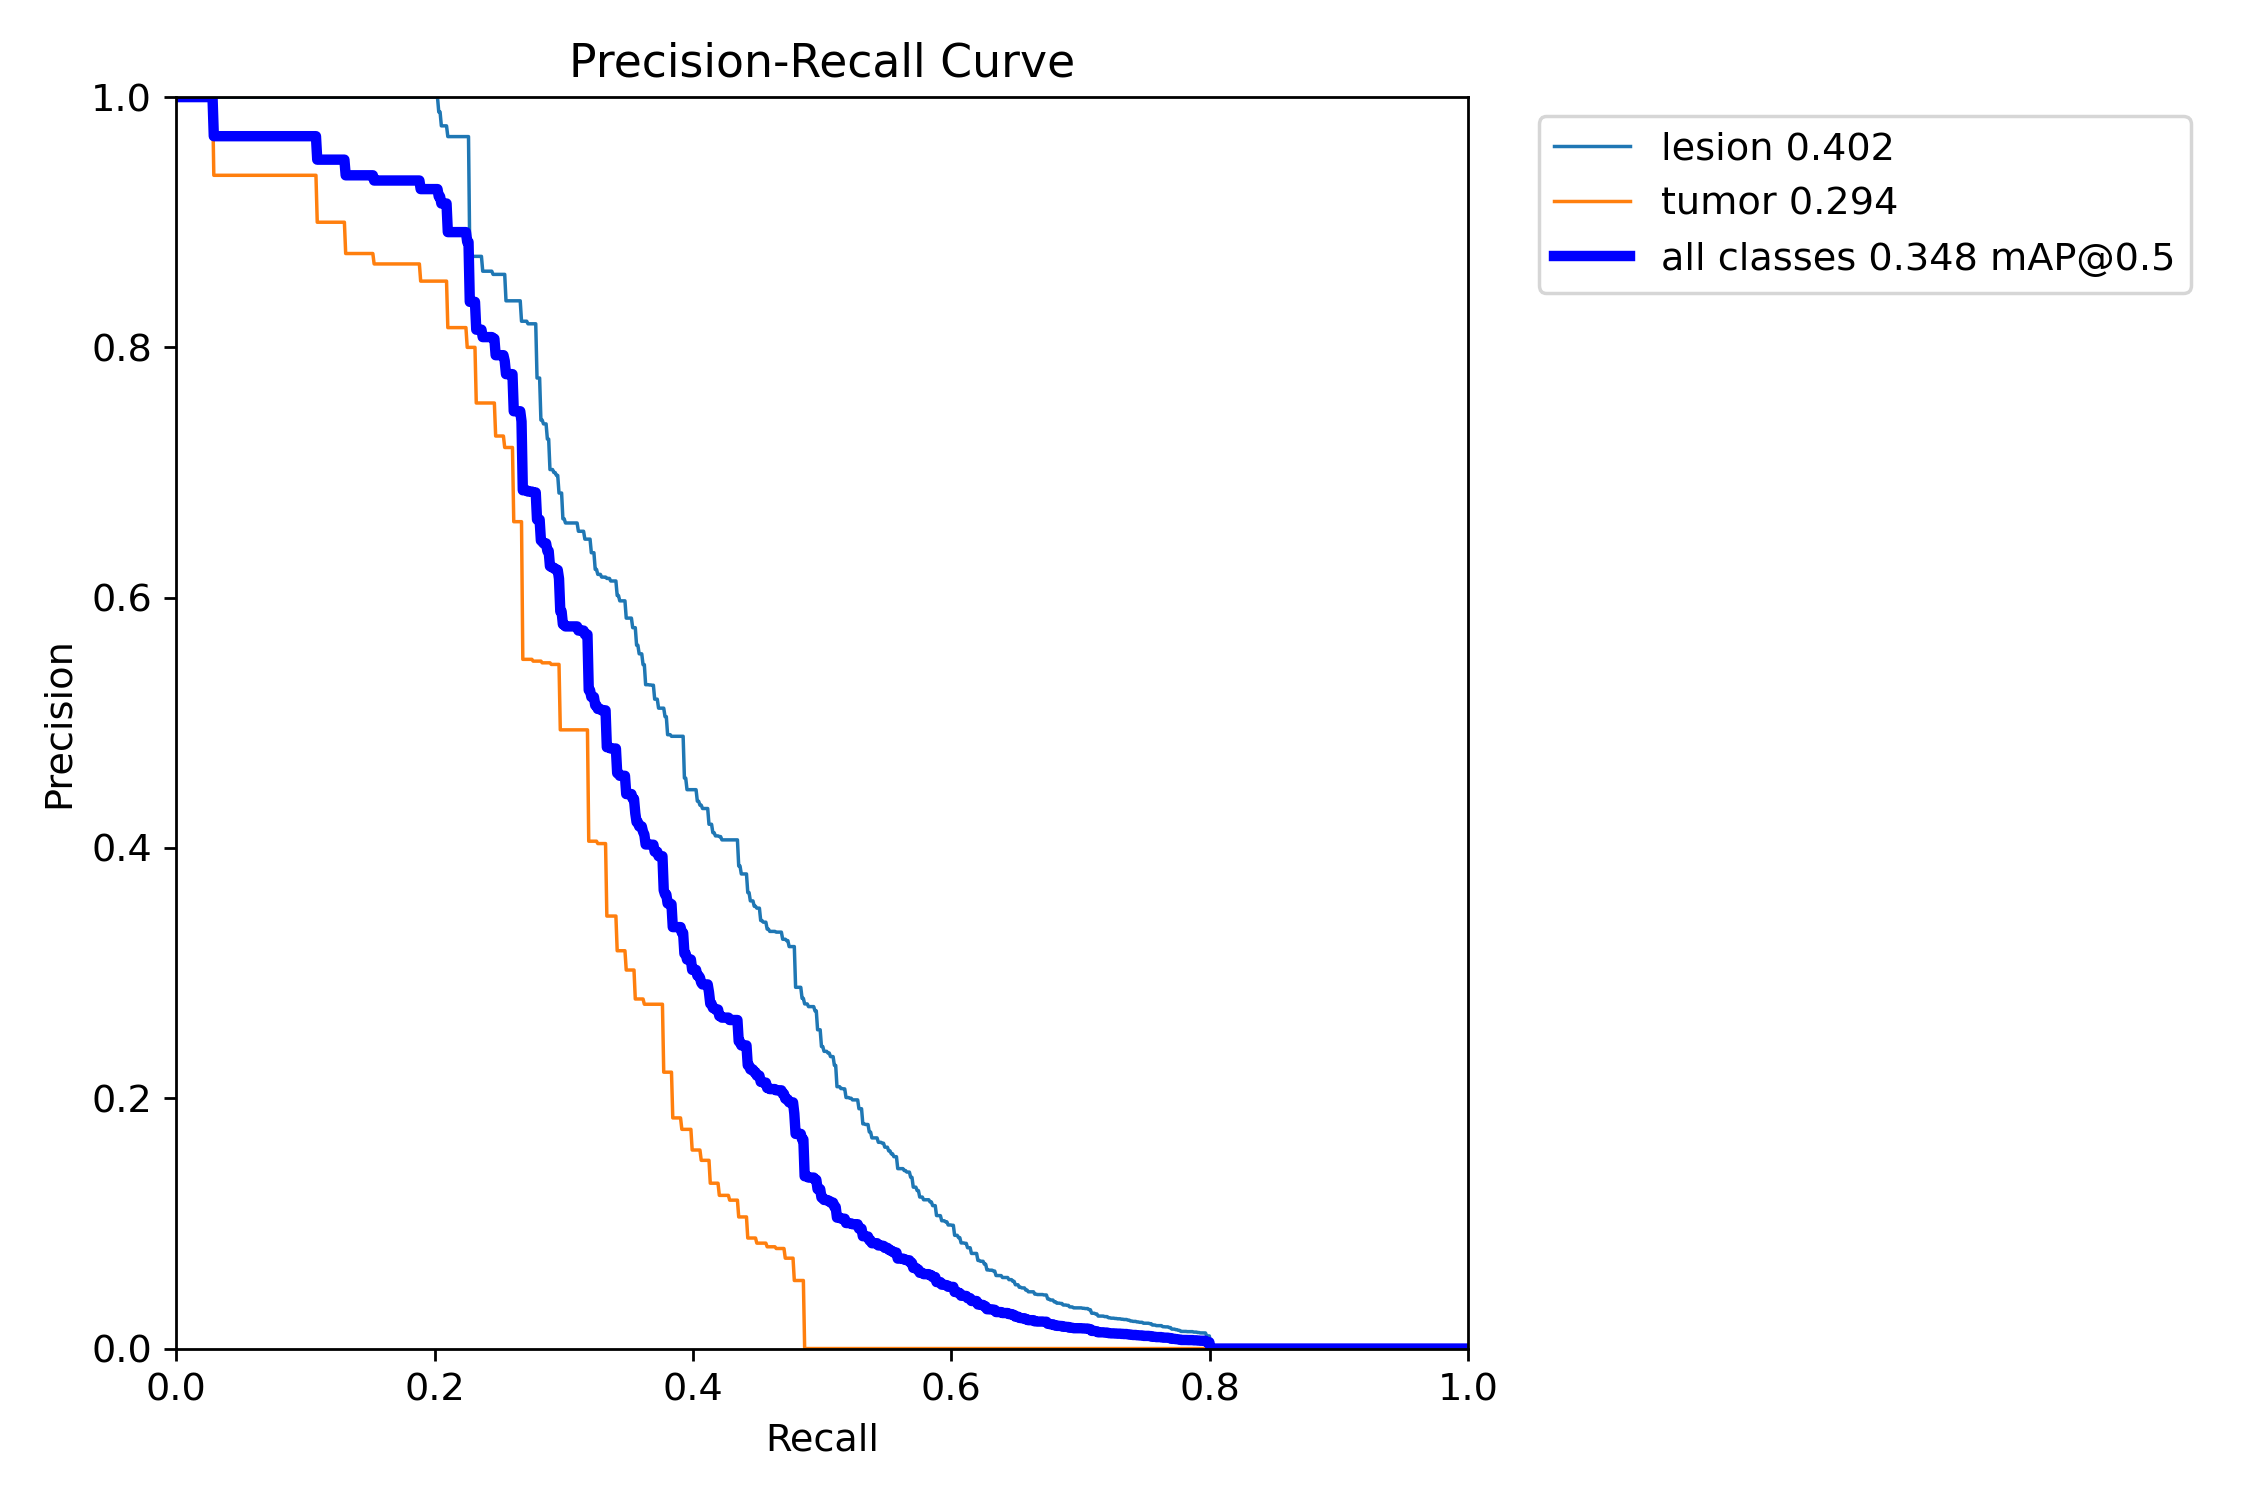

In [15]:
from IPython.display import Image, display

for candidates, title, width in [
    (['results.png'], '📈 Full training curves (auto-saved)', 950),
    (['confusion_matrix_normalized.png', 'confusion_matrix.png'], '🔍 Confusion Matrix', 620),
    (['BoxF1_curve.png', 'F1_curve.png'], '🎯 F1 vs Confidence', 620),
    (['BoxPR_curve.png', 'PR_curve.png'], '📉 Precision–Recall Curve', 620),
]:
    for fname in candidates:
        p = os.path.join(exp_dir, fname)
        if os.path.exists(p):
            print(title)
            display(Image(filename=p, width=width))
            break

## 15. 🏅 FROC Analysis — The Clinical Gold Standard
COCO mAP is a *computer-vision* metric. Mammography CAD papers (and FDA CADe guidance) evaluate with the **Free-Response ROC**: **lesion sensitivity vs. false positives per image (FP/I)** across the full confidence sweep.

Method:
1. Export low-threshold predictions (`conf=0.01`, with confidences) on the test set.
2. Sweep the confidence threshold; at each point, greedily match predictions to ground truth at **IoU ≥ 0.5**.
3. Plot sensitivity vs FP/I, and read sensitivity at the clinically standard operating rates **0.5 / 1 / 2 FP/I**.

Results saved to /content/clinical_eval/test_preds
200 labels saved to /content/clinical_eval/test_preds/labels


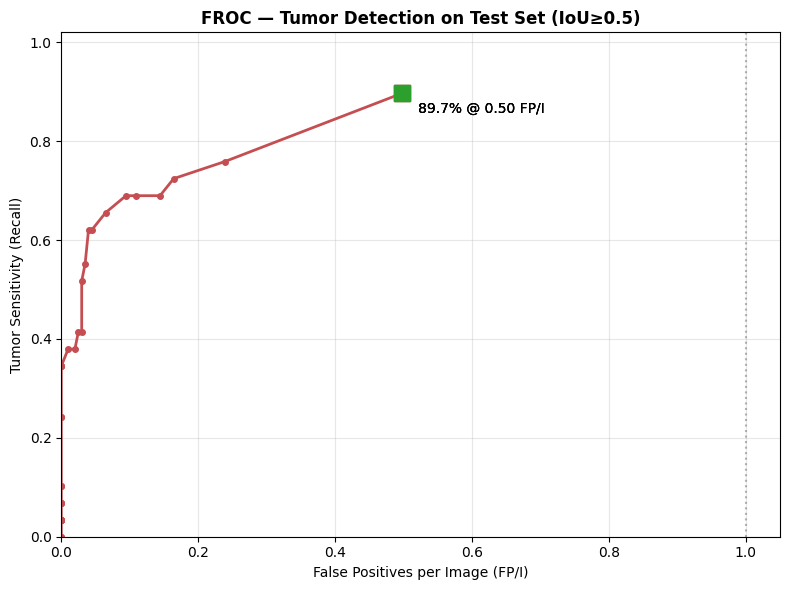

🏅 FROC SUMMARY (tumor class)
   FP/I range actually reachable in this run: 0.000 -- 0.498
   Sensitivity at ~0.5 FP/I : 89.7%  (threshold=0.01)
   Sensitivity at ~1.0 FP/I : 89.7%  (threshold=0.01)  [!] target FP/I=1.0 NOT reached in tested range -- closest available point, not a real operating point at that FP/I
   Sensitivity at ~2.0 FP/I : 89.7%  (threshold=0.01)  [!] target FP/I=2.0 NOT reached in tested range -- closest available point, not a real operating point at that FP/I

CHOSEN OPERATING POINT (FP/I <= 1.0): conf=0.01 -> tumor sensitivity=89.7%, FP/I=0.50
This threshold -- not an arbitrary constant -- is what the bootstrap section below uses.


In [16]:
test_images_dir = '/content/breast_dataset/test/images'

best_model.predict(
    source=test_images_dir, conf=0.01, iou=0.6,
    save_txt=True, save_conf=True,
    project='/content/clinical_eval', name='test_preds',
    exist_ok=True, verbose=False
)
pred_labels_dir = '/content/clinical_eval/test_preds/labels'

# ---------- shared helpers (reused in Sections 16-17) ----------
def xywhn_to_xyxy(boxes):
    boxes = np.asarray(boxes, dtype=float).reshape(-1, 4)
    x1 = boxes[:, 0] - boxes[:, 2] / 2
    y1 = boxes[:, 1] - boxes[:, 3] / 2
    x2 = boxes[:, 0] + boxes[:, 2] / 2
    y2 = boxes[:, 1] + boxes[:, 3] / 2
    return np.stack([x1, y1, x2, y2], axis=1)

def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    lt = np.maximum(a[:, None, :2], b[None, :, :2])
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.clip(rb - lt, 0, None)
    inter = wh[:, :, 0] * wh[:, :, 1]
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / np.maximum(area_a[:, None] + area_b[None, :] - inter, 1e-9)

test_imgs = list_images('test')

gt_by_img, pred_by_img = {}, {}
for p in test_imgs:
    lp = label_path_for(p)
    boxes = []
    if os.path.exists(lp):
        with open(lp) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    boxes.append([int(float(parts[0]))] + [float(x) for x in parts[1:5]])
    gt_by_img[p] = boxes
    stem = os.path.basename(p).rsplit('.', 1)[0]
    pp = os.path.join(pred_labels_dir, stem + '.txt')
    dets = []
    if os.path.exists(pp):
        with open(pp) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 6:
                    dets.append([int(float(parts[0]))] + [float(x) for x in parts[1:5]] + [float(parts[5])])
    pred_by_img[p] = dets

def match_at_threshold(conf_thr, target_cls, iou_thr=0.5):
    total_gt = total_tp = total_fp = 0
    per_img = {}
    for img in test_imgs:
        gt = [b for b in gt_by_img[img] if b[0] == target_cls]
        pr = sorted([d for d in pred_by_img[img] if d[0] == target_cls and d[5] >= conf_thr],
                    key=lambda d: -d[5])
        ious = iou_matrix(xywhn_to_xyxy([d[1:5] for d in pr]),
                          xywhn_to_xyxy([b[1:5] for b in gt]))
        matched = np.zeros(len(gt), dtype=bool)
        tp = 0
        for i in range(len(pr)):
            if len(gt) == 0:
                break
            j = int(np.argmax(ious[i]))
            if ious[i, j] >= iou_thr and not matched[j]:
                matched[j] = True
                tp += 1
        fp = len(pr) - tp
        fn = len(gt) - tp
        total_gt += len(gt); total_tp += tp; total_fp += fp
        per_img[img] = (tp, fp, fn)
    return total_gt, total_tp, total_fp, per_img

TUMOR_ID = class_names.index('tumor')
conf_grid = np.linspace(0.01, 0.95, 40)
sens, fpi = [], []
for thr in conf_grid:
    tg, tp, fp, _ = match_at_threshold(thr, TUMOR_ID)
    sens.append(tp / tg if tg else 0.0)
    fpi.append(fp / len(test_imgs))
sens, fpi = np.array(sens), np.array(fpi)

plt.figure(figsize=(8, 6))
plt.plot(fpi, sens, 'o-', color='#C44E52', lw=2, ms=4)
for target in [0.5, 1.0, 2.0]:
    idx = int(np.argmin(np.abs(fpi - target)))
    plt.plot(fpi[idx], sens[idx], 's', ms=11)
    plt.annotate(f"{sens[idx] * 100:.1f}% @ {fpi[idx]:.2f} FP/I",
                 (fpi[idx], sens[idx]), textcoords='offset points', xytext=(12, -14), fontsize=10)
plt.axvline(1.0, ls=':', c='gray', alpha=0.6)
plt.xlabel('False Positives per Image (FP/I)')
plt.ylabel('Tumor Sensitivity (Recall)')
plt.title('FROC — Tumor Detection on Test Set (IoU≥0.5)', fontweight='bold')
plt.grid(alpha=0.3); plt.xlim(left=0); plt.ylim(0, 1.02)
plt.tight_layout(); plt.show()

print("🏅 FROC SUMMARY (tumor class)")
print(f"   FP/I range actually reachable in this run: {fpi.min():.3f} -- {fpi.max():.3f}")
for target in [0.5, 1.0, 2.0]:
    idx = int(np.argmin(np.abs(fpi - target)))
    reached = abs(fpi[idx] - target) < 0.15
    tag = "" if reached else f"  [!] target FP/I={target} NOT reached in tested range -- closest available point, not a real operating point at that FP/I"
    print(f"   Sensitivity at ~{target} FP/I : {sens[idx] * 100:.1f}%  (threshold={conf_grid[idx]:.2f}){tag}")

# Turn the FROC curve into an ACTUAL decision instead of three disconnected numbers.
# Clinical rule (state and defend this in your report, don't just assert a number):
#   pick the highest tumor sensitivity achievable while keeping FP/I <= 1.0 per image.
FPI_BUDGET = 1.0
feasible = np.where(fpi <= FPI_BUDGET)[0]
if len(feasible) > 0:
    best_idx = feasible[np.argmax(sens[feasible])]
    CONF_OP_CHOSEN = float(conf_grid[best_idx])
    print(f"\nCHOSEN OPERATING POINT (FP/I <= {FPI_BUDGET}): "
          f"conf={CONF_OP_CHOSEN:.2f} -> tumor sensitivity={sens[best_idx]*100:.1f}%, FP/I={fpi[best_idx]:.2f}")
else:
    CONF_OP_CHOSEN = float(conf_grid[int(np.argmin(fpi))])
    print(f"\nNo threshold in the tested range satisfies FP/I <= {FPI_BUDGET}; "
          f"falling back to the lowest-FP/I point tested: conf={CONF_OP_CHOSEN:.2f}")
print("This threshold -- not an arbitrary constant -- is what the bootstrap section below uses.")


## 16. Bootstrap 95% Confidence Intervals
A point metric on 201 test images is an *estimate* — top venues require its uncertainty. We resample test images **with replacement (1,000 bootstrap replicates)** and recompute the operating-point metrics each time, reporting 95% percentile intervals. This is the same machinery used in clinical ML papers (e.g., mAP ± CI in breast-ultrasound YOLO studies).

Using FROC-derived operating point: conf=0.01
📐 BOOTSTRAP 95% CIs  (1,000 resamples, conf=0.01, IoU≥0.5)
   Precision (all): 0.110   95% CI [0.097, 0.125]
   Recall (all)   : 0.750   95% CI [0.691, 0.808]
   F1 (all)       : 0.192   95% CI [0.171, 0.215]
   Tumor Recall   : 0.897   95% CI [0.783, 1.000]


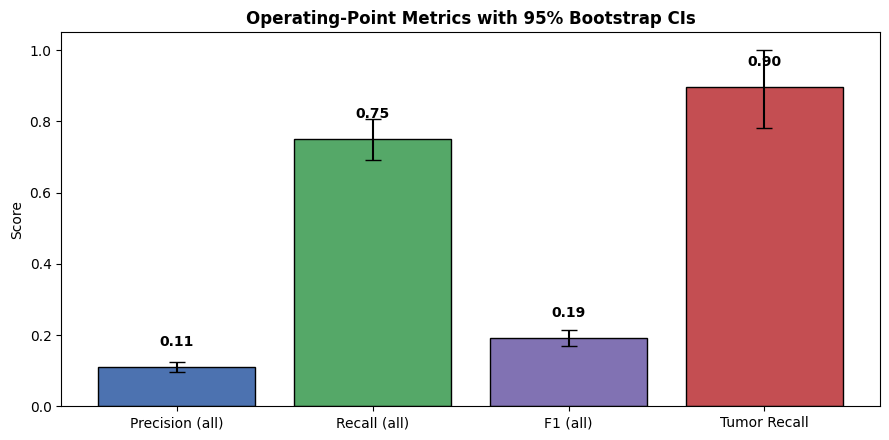

In [17]:
CONF_OP = CONF_OP_CHOSEN   # derived in Section 16's FROC sweep, not an arbitrary constant
print(f"Using FROC-derived operating point: conf={CONF_OP:.2f}")
rng = np.random.default_rng(SEED)

# per-image TP/FP/FN for BOTH classes at the operating point
per_image_counts = {}
for cls_id in range(NUM_CLASSES):
    _, _, _, pim = match_at_threshold(CONF_OP, cls_id)
    for img, (tp, fp, fn) in pim.items():
        per_image_counts.setdefault(img, {})[cls_id] = (tp, fp, fn)

imgs_arr = np.array(list(per_image_counts.keys()))

def metrics_from(sample):
    tp = fp = fn = t_tp = t_fn = 0
    for im in sample:
        for c, (t, f, n) in per_image_counts[im].items():
            tp += t; fp += f; fn += n
            if c == TUMOR_ID:
                t_tp += t; t_fn += n
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F1 = 2 * P * R / (P + R) if P + R else 0.0
    tR = t_tp / (t_tp + t_fn) if t_tp + t_fn else 0.0
    return P, R, F1, tR

boot = np.array([metrics_from(rng.choice(imgs_arr, size=len(imgs_arr), replace=True))
                 for _ in range(1000)])
point = metrics_from(imgs_arr)
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)

labels = ['Precision (all)', 'Recall (all)', 'F1 (all)', 'Tumor Recall']
print("=" * 66)
print(f"📐 BOOTSTRAP 95% CIs  (1,000 resamples, conf={CONF_OP}, IoU≥0.5)")
print("=" * 66)
for k, lab in enumerate(labels):
    print(f"   {lab:<15}: {point[k]:.3f}   95% CI [{lo[k]:.3f}, {hi[k]:.3f}]")
print("=" * 66)

fig, ax = plt.subplots(figsize=(9, 4.5))
pos = np.arange(len(labels))
ax.bar(pos, point, yerr=[point - lo, hi - point], capsize=6,
       color=['#4C72B0', '#55A868', '#8172B3', '#C44E52'], edgecolor='black')
ax.set_xticks(pos); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Operating-Point Metrics with 95% Bootstrap CIs', fontweight='bold')
for i, v in enumerate(point):
    ax.text(i, v + 0.06, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 17. Error Analysis — Learning from Failures
Aggregate metrics never tell the *whole* story. We directly visualize the two failure modes at the operating point:
- **False negatives** — missed tumors (clinically the dangerous one).
- **False positives** — phantom alarms (drive radiologist distrust).

Tumor FN images (missed tumors): 3
Tumor FP images (false alarms) : 39


/tmp/ipykernel_3184/4070365124.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


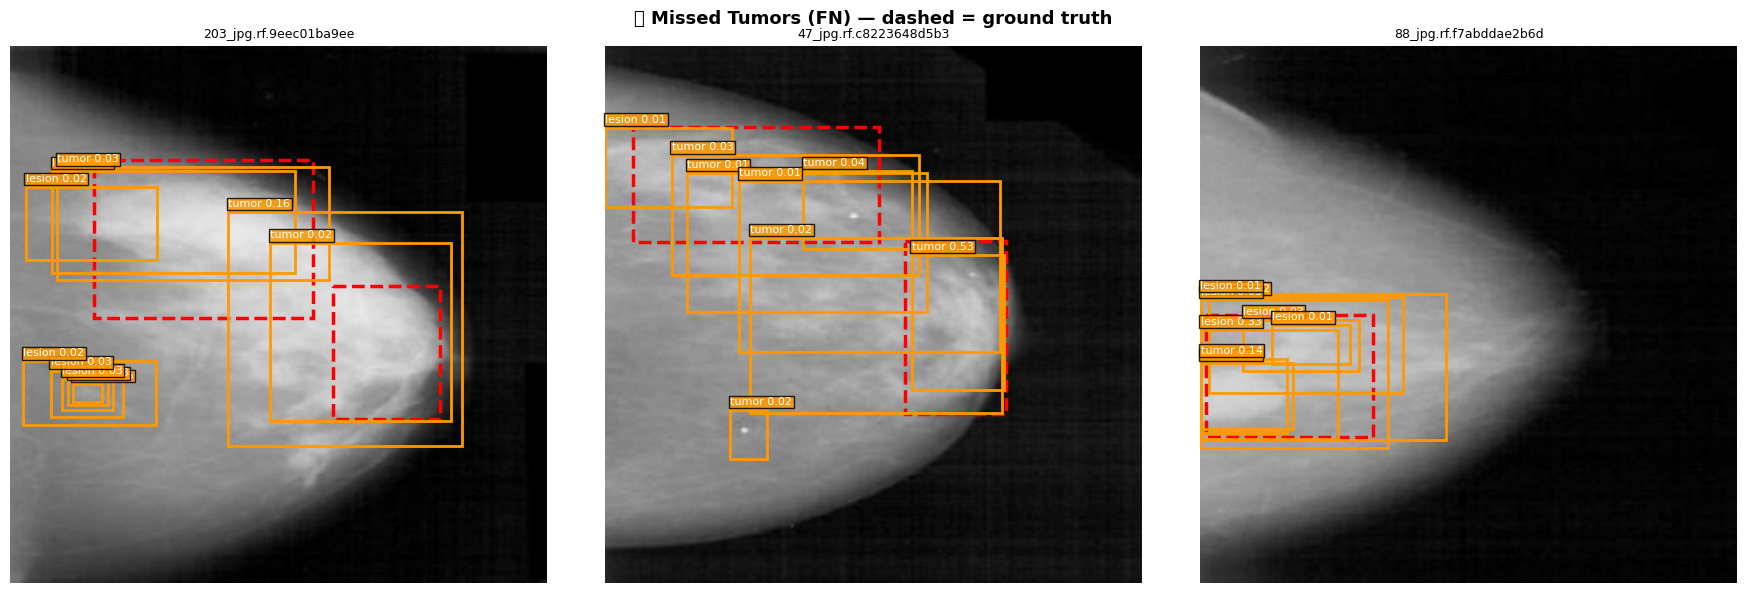

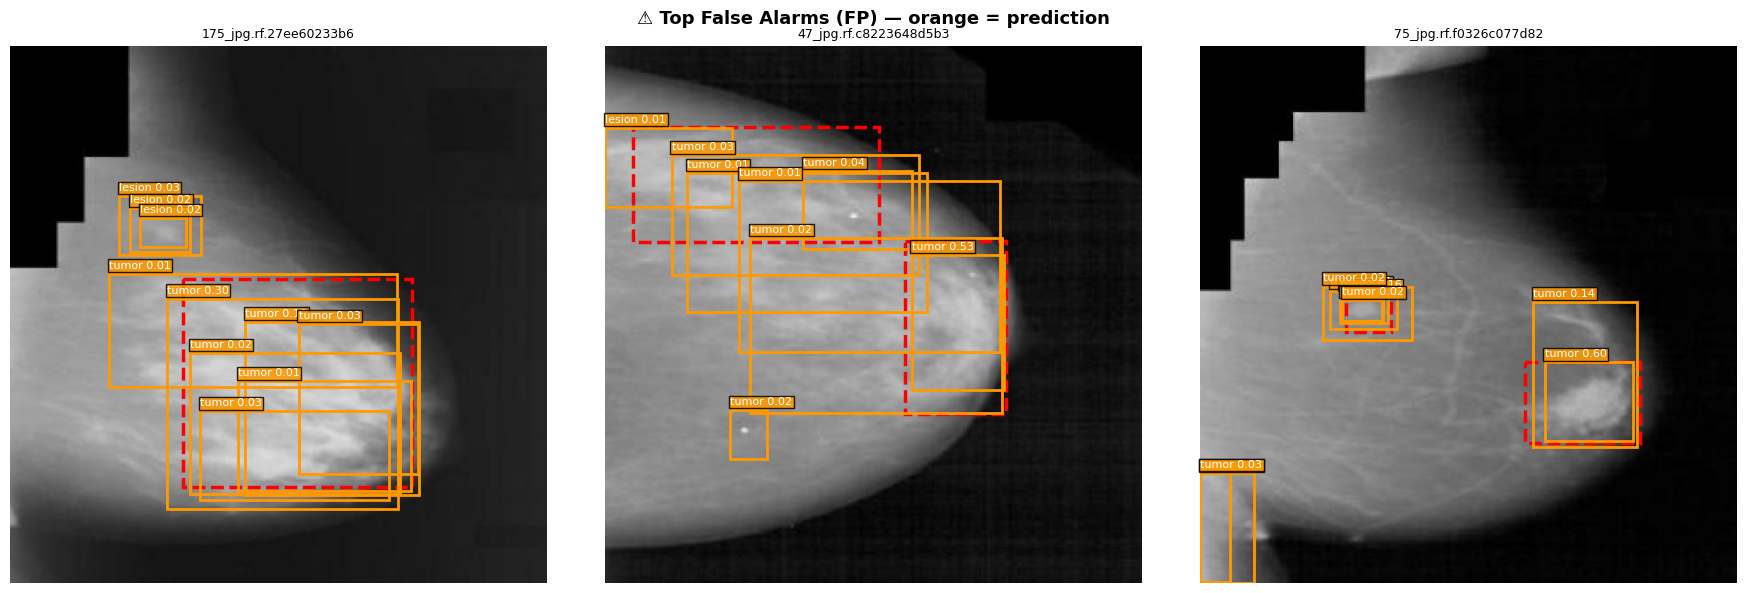

In [18]:
_, _, _, tumor_per_img = match_at_threshold(CONF_OP, TUMOR_ID)

fn_imgs = [im for im, (tp, fp, fn) in tumor_per_img.items() if fn > 0]
fp_imgs = sorted([im for im, v in tumor_per_img.items() if v[1] > 0],
                 key=lambda im: -tumor_per_img[im][1])

print(f"Tumor FN images (missed tumors): {len(fn_imgs)}")
print(f"Tumor FP images (false alarms) : {len(fp_imgs)}")

def draw_case(img_path, ax):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    for b in gt_by_img[img_path]:
        x1y1 = xywhn_to_xyxy([b[1:5]])[0]
        x1, y1, x2, y2 = x1y1 * [w, h, w, h]
        col = CLASS_COLORS_RGB.get(b[0], (1, 1, 0))
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor=col, linewidth=2.5, linestyle='--'))
    for d in pred_by_img[img_path]:
        if d[5] < CONF_OP:
            continue
        x1y1 = xywhn_to_xyxy([d[1:5]])[0]
        x1, y1, x2, y2 = x1y1 * [w, h, w, h]
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor=(1, 0.6, 0), linewidth=2))
        ax.text(x1, max(y1 - 6, 10), f"{class_names[d[0]]} {d[5]:.2f}", color='white',
                fontsize=8, bbox=dict(facecolor=(1, 0.6, 0), alpha=0.85, pad=1))
    ax.imshow(img); ax.axis('off')
    ax.set_title(os.path.basename(img_path)[:22], fontsize=9)

cases = (fn_imgs[:3], fp_imgs[:3])
titles = ('❌ Missed Tumors (FN) — dashed = ground truth', '⚠️ Top False Alarms (FP) — orange = prediction')
for row, (subset, title) in enumerate(zip(cases, titles)):
    if not subset:
        continue
    fig, axes = plt.subplots(1, len(subset), figsize=(6 * len(subset), 6))
    axes = np.array(axes).reshape(-1)
    for ax, im in zip(axes, subset):
        draw_case(im, ax)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## 18. Qualitative Predictions
Final visual sanity check at the operating point (`conf=0.35`).

In [ ]:
best_model.predict(
    source=test_images_dir, conf=0.35, iou=0.50,
    save=True, project='/content/predictions', name='final_test_predictions',
    exist_ok=True, verbose=False
)
pred_dir = '/content/predictions/final_test_predictions'
predicted = sorted(glob.glob(f'{pred_dir}/*.jpg') + glob.glob(f'{pred_dir}/*.png'))[:6]

if predicted:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.reshape(-1)
    for idx, p_img in enumerate(predicted):
        axes[idx].imshow(cv2.cvtColor(cv2.imread(p_img), cv2.COLOR_BGR2RGB))
        axes[idx].set_title(os.path.basename(p_img)[:26], fontsize=9)
        axes[idx].axis('off')
    for j in range(len(predicted), 6):
        axes[j].axis('off')
    plt.suptitle('YOLO11s Predictions on Test Mammograms (conf=0.35)', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

In [20]:
print("=" * 66)
print("THIS RUN -- actual computed numbers (not hardcoded)")
print("=" * 66)
print(f"   mAP@50 (test, conf=0.30 default val)      : {test_metrics.box.map50:.3f}")
print(f"   mAP@50-95 (test, conf=0.30 default val)    : {test_metrics.box.map:.3f}")
print(f"   Chosen operating point (Sec.16 FROC)       : conf={CONF_OP_CHOSEN:.2f}")
print(f"   Tumor recall @ chosen operating point      : {point[3]:.3f}  "
      f"95% CI [{lo[3]:.3f}, {hi[3]:.3f}]")
print("=" * 66)
print("Use THESE numbers in your report/defense -- not any number typed in a previous "
      "draft or a different run.")


THIS RUN -- actual computed numbers (not hardcoded)
   mAP@50 (test, conf=0.30 default val)      : 0.430
   mAP@50-95 (test, conf=0.30 default val)    : 0.245
   Chosen operating point (Sec.16 FROC)       : conf=0.01
   Tumor recall @ chosen operating point      : 0.897  95% CI [0.783, 1.000]
Use THESE numbers in your report/defense -- not any number typed in a previous draft or a different run.


---
## Part D — Discussion
## 19. Positioning vs. Published Literature

| Study (peer-reviewed) | Model | Dataset | mAP@50 |
|:---|:---|:---|:---:|
| Quiñones-Espín et al. 2023 (Health Technol.) | YOLOv5x | VinDr-Mammo → MIAS (test) | 0.488 |
| YOLOv9 + OMI-DB pretraining 2025 (PubMed 40602320) | YOLOv9 + large-scale domain pretraining | Proprietary | 0.733 ± 0.167 |
| Al-masni / YOLO-CAD family | YOLO + classifier fusion | DDSM / INbreast | ~0.90+ (engineered pipelines) |
| **This work** | **YOLO11s (vanilla, COCO transfer)** | Roboflow BCD v2 | *(computed live in the cell below — no fixed number stated here, so this table can never go stale)* |

**Reading:** vanilla YOLO backbones without domain-specific pretraining or architecture surgery cluster in the **0.44–0.60 mAP@50** band on mammography — our result sits squarely inside the published envelope. The gap to 0.73+ is closed in the literature mainly via (a) pretraining on large mammography corpora (OMI-DB) and (b) architectural modifications — both stated as future work below.

## 20. Limitations & Future Work
1. **Class imbalance (~7:1)** toward `lesion` — mitigated analytically (per-class metrics, FROC), not by resampling, to preserve real prevalence. Future: copy-paste augmentation of tumors.
2. **Small tumor test sample** (29 boxes) → wide bootstrap CIs on tumor recall; honest uncertainty is reported rather than hidden.
3. **Single-source dataset** → external validation (e.g., CBIS-DDSM, VinDr-Mammo) is the next step for generalization claims.
4. **CLAHE ablation** (Section 8) — published evidence suggests inference-time CLAHE recovers missed low-contrast lesions; left as a controlled experiment.
5. **Domain pretraining / larger backbones** (`yolo11m`, `imgsz=1024`) for tiny lesions near the detection floor.

## 21. Model Card & References
**Model:** YOLO11s · 9.4M params · input 640×640 · trained 70 epochs, batch 8, cos-LR, seed 42 · Tesla T4 (~2 h) · **Intended use:** research/education only — **not** a medical device.

**References**
1. Roboflow Universe — Breast Cancer Detection v2 (CC BY 4.0). universe.roboflow.com/breast-cancer-detection-roclf/breast-cancer-detection-jixc0/dataset/2
2. Ultralytics YOLO11 — docs.ultralytics.com
3. Quiñones-Espín et al., *Automatic detection of breast masses using deep learning with YOLO approach*, Health Technol. 13(6), 2023.
4. *Improving YOLO-based breast mass detection with transfer learning pretraining on the OPTIMAM Mammography Image Database*, PubMed 40602320, 2025.
5. FDA — *Clinical Performance Assessment: Considerations for CADe Devices* (FROC/LROC endpoints).
6. Al-masni et al., *Simultaneous detection and classification of breast masses via YOLO-based CAD*, DDSM/INbreast.
7. Baccouche et al., *Breast-YOLO* fused detection-classification, 2021.
8. Efron & Tibshirani, *An Introduction to the Bootstrap*, 1993.